# CNOT

In [1]:
import sys
sys.path.append('../')

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import ham_data as hd
from truncation_estimate import trunc_by_thresh, trunc_by_graph_estimate
import utils_2Q_gate_zp as ut

# Reset to the default Matplotlib color cycle
plt.rcParams['axes.prop_cycle'] = plt.rcParamsDefault['axes.prop_cycle']

cnot = pd.read_csv('data/cnot_fidelity_npz.txt')
# df = pd.DataFrame(p, columns=['tg', 'drive_amp_1', 'drive_amp_2', 'detune_1',
#                                    'detune_2', 'f_200_select', 'f_1000_False',  ])
# df.to_csv('data/data_cnot_fidelity_3ncut.txt', sep=',', index=False, header=True)

# tg_list = [50, 120, 190, 260, 330]
# msteps = [1e-5, 3e-5, 1e-4, 3e-4, 1e-3]

In [ ]:
folder_load='../../data/_truc_3000/'
data = np.load(folder_load+ 'two_qubit_data.npz', allow_pickle=True)
for i in data.keys():
    print(i)

eval1
eval2
evecs1
evecs2
n_theta1
n_theta2
hspace_1_charge
hspace_2_charge
g_theta1theta2
evals_tot
evecs_tot
hspace_full
n_theta1_dressed
n_theta2_dressed
top_idx
top_overlap
hspace_n_theta1
hspace_n_theta2
params


In [84]:
import ham_data as hd
folder_load='../data/December_17_2025_Sorted_Untruc'
(hspace_full, eket_tot, eval_tot, n_theta0_dress,
    n_theta1_dress, hspace_0, hspace_1, logi_state) = hd.load_two_qubit_data(
    folder_load, return_full=False
)
# print(hspace_full[:20])
# print(eval_tot[:20])
# print(np.shape(n_theta1_dress), len(hspace_full))

## Gate optimization duration vs tg

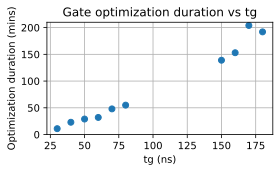

: 

In [ ]:
from datetime import datetime

# ============================================================
# 原始数据： (start_time, tg_init)
# ============================================================
data = [
    ("2025-12-27 16:48", 30),
    ("2025-12-27 16:59", 40),
    ("2025-12-27 17:22", 50),
    ("2025-12-27 17:51", 60),
    ("2025-12-27 18:23", 70),
    ("2025-12-27 19:11", 80),
    ("2025-12-27 20:06", 90),
    ("2025-12-28 04:32", 150),
    ("2025-12-28 06:51", 160),
    ("2025-12-28 09:24", 170),
    ("2025-12-28 12:48", 180),
    ("2025-12-28 16:00", 190),
]

# ============================================================
# 解析时间
# ============================================================
times = [datetime.strptime(t, "%Y-%m-%d %H:%M") for t, _ in data]
tg = [tg for _, tg in data]

# ============================================================
# 计算每个 tg 的优化耗时（分钟）
# duration(tg_i) = start_time(tg_{i+1}) - start_time(tg_i)
# ============================================================
tg_used = []
durations_min = []

for i in range(len(times) - 1):
    dt_min = (times[i + 1] - times[i]).total_seconds() / 60
    tg_used.append(tg[i])
    durations_min.append(dt_min)

# ============================================================
# 作图
# ============================================================
plt.figure(figsize=(4, 2.5))
plt.plot(tg_used, durations_min, "o", lw=2)

plt.ylim(0,210)
plt.xlabel("tg (ns)")
plt.ylabel("Optimization duration (mins)")
plt.title("Gate optimization duration vs tg")
plt.grid(True)

plt.tight_layout()
plt.savefig("result.png", dpi=300)

2025-12-27 
16:48 tg_init=30 start
16:59 tg_init=40
17:22 tg_init=50
17:51 tg_init=60
18:23 tg_init=70
19:11 tg_init=80
20:06 tg_init=90

2025-12-28 
4:32 tg_init=150
6:51 tg_init=160
9:24 tg_init=170
12:48 tg_init=180
16:00 tg_init=190


In [90]:
truc_model = {}
truc_model['n_theta_dress_charge_truc'] = [
0, 1, 2, 3, 5, 7, 8, 9, 10, 12, 14, 16, 20, 21, 25, 26, 27, 28, 31, 33 ,
]
hspace_select = np.array(hspace_full)[ truc_model['n_theta_dress_charge_truc'][:4]].tolist()
hspace_select

['0-0', '0-1', '1-0', '0-2']

In [89]:
hspace_select = np.array(hspace_full)[[0,1,2]].tolist()
hspace_select

['0-0', '0-1', '1-0']

In [ ]:
thresh = 1e-2
logi_state = ['0-0', '0-2', '2-0', '2-2']
logi_idx = [hspace_full.index(state) for state in logi_state]
# logi_idx

h_tot_0_truc_idx = trunc_by_thresh(logi_idx, n_theta0_dress, thresh=thresh)
h_tot_1_truc_idx = trunc_by_thresh(logi_idx, n_theta1_dress, thresh=thresh)
print(f'thresh = {thresh}')
print(f'len(h_tot_0_truc_idx) = {len(h_tot_0_truc_idx)}')
print(f'len(h_tot_1_truc_idx) = {len(h_tot_1_truc_idx)}')

thresh = 0.01
len(h_tot_0_truc_idx) = 966
len(h_tot_1_truc_idx) = 966


In [74]:
# ut.compare_two_lists(h_tot_0_truc_idx, h_tot_1_truc_idx)


In [ ]:
data = h_tot_0_truc_idx
dim = 20
for i in range(0, len(data), dim):  # Step size of 10
    if i%100==0:
        print('')
    # print(", ".join(f"'{x}'" for x in data[i:i + dim]), ',') # print string format
    print(", ".join(f"{x}" for x in data[i:i + dim]), ',') # print integer format


0, 1, 2, 3, 5, 7, 8, 9, 10, 12, 14, 16, 20, 21, 25, 26, 27, 28, 31, 33 ,
35, 37, 39, 43, 45, 49, 50, 54, 55, 58, 62, 63, 64, 68, 71, 73, 76, 78, 80, 82 ,
85, 87, 93, 96, 98, 99, 101, 105, 106, 110, 112, 115, 117, 119, 120, 121, 127, 129, 133, 134 ,
135, 136, 139, 140, 144, 146, 151, 155, 160, 163, 167, 169, 171, 172, 174, 181, 182, 187, 189, 190 ,
193, 194, 197, 200, 204, 208, 209, 210, 211, 212, 216, 218, 220, 225, 226, 227, 230, 238, 240, 241 ,

244, 245, 247, 252, 254, 255, 258, 259, 261, 262, 264, 267, 269, 274, 275, 279, 282, 288, 296, 303 ,
304, 305, 306, 308, 310, 312, 315, 321, 323, 324, 333, 334, 340, 343, 344, 346, 353, 354, 356, 359 ,
361, 364, 365, 370, 372, 374, 375, 377, 378, 379, 383, 387, 388, 389, 391, 393, 398, 403, 406, 409 ,
412, 414, 416, 417, 418, 420, 424, 425, 426, 429, 430, 432, 434, 437, 450, 451, 453, 454, 461, 463 ,
466, 468, 470, 472, 473, 475, 483, 486, 494, 495, 496, 501, 502, 514, 524, 527, 528, 535, 536, 537 ,

539, 545, 549, 550, 553, 555, 556, 558, 5

## Fidelity

In [ ]:
tg_vec = np.arange(30, 351, 10)
f_400 = np.array([
-0.32297679, -0.41025537, -0.51653568, -0.62977484 ,
-0.74216980, -0.83672022, -0.90619469, -0.99917585 ,
-1.14518348, -1.33196711, -1.53704330, -1.71932607 ,
-1.84644641 ,
-1.98411282, -2.16917388, -2.34213818 ,
-2.49193587, -2.64316566, -2.78053070, -2.87570506 ,
-2.95980974, -3.05093425, -3.12372119, -3.17791560 ,
-3.24106422, -3.30329874 ,
-3.34935708,
-3.39127428, -3.44410691, -3.48675748, -3.52464473 ,
-3.56270127, -3.60722379 ,
])
f_1000 = np.array([
-0.32093210, -0.40827203, -0.51470948, -0.62789940 ,
-0.74043991, -0.83569142, -0.90790866, -1.00014384 ,
-1.14607615, -1.33406571, -1.54178217, -1.72897327 ,
-1.85331970 ,
-1.98303166, -2.15718068, -2.31950511 ,
-2.46472687, -2.61851970, -2.76232657, -2.86433789 ,
-2.95548377, -3.05007457, -3.12449443, -3.17925928 ,
-3.24231819, -3.30473353 , -3.35098033,
-3.39423504, -3.44811776, -3.48931498, -3.52757268 ,
-3.56552601, -3.60965507 ,
])

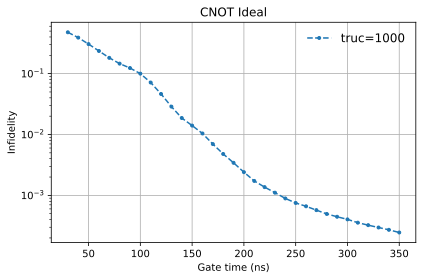

In [14]:
fig, ax = plt.subplots(1,1,figsize=(6,4))
ax.set_title('CNOT from npz')
# ax.plot(tg_vec, 10**f_400, '.--', label='truc=400')
ax.plot(tg_vec, 10**f_1000, '.--', label='truc=1000')

# ax.plot(tg_vec, np.abs(10**f_400 - 10**f_1000), ':',  label=r'difference: mstep=1e-3')
# ax.set_title(fr'CNOT Ideal, Pulse optimized from Truc=400', fontsize=12)
ax.set_title(fr'CNOT Ideal', fontsize=12)
ax.set_ylabel('Infidelity')
ax.set_xlabel('Gate time (ns)')
ax.set_yscale('log')
ax.legend(framealpha=0, fontsize=12)
ax.grid()
plt.tight_layout()
plt.savefig('result.png', dpi=300, bbox_inches='tight')

## Truc_low=3000 vs Truc_charge=220

In [2]:
fname = "data/fidelity_vs_real_truncation_and_tg.txt"
data = np.loadtxt(fname, delimiter=",")
tg_vec = data[:, 0]
f_real = data[:, 1:]   # shape: (Nt, Ntruc)
truc_real = [200, 400, 600, 800, 1000, 2000, 3000]

fname = "data/fidelity_vs_charge_picked_truncation_and_tg.txt"
data = np.loadtxt(fname, delimiter=",")
f_charge = data[:, 1:]   # shape: (Nt, Ntruc)
truc_charge = [200, 220, 240, 260, 280, 300, 320, 340, 360, 380, 400, 500, 600, 700, 800, 900]

In [ ]:
params = np.array([
### From charge-truc=400        
[29.994376, 0.099205, 0.057109, -0.028523, -0.027362] ,
[40.003004, 0.096609, 0.049579, -0.028325, -0.026694] ,
[50.009627, 0.086208, 0.045334, -0.026182, -0.024551] ,
[59.995626, 0.077544, 0.041816, -0.024491, -0.02316] ,
[70.001584, 0.070142, 0.037217, -0.020717, -0.019962] ,
[79.999318, 0.064654, 0.035147, -0.019493, -0.019465] ,
[90.004152, 0.05837, 0.033131, -0.016679, -0.016419] ,
[99.993121, 0.054087, 0.03088, -0.01407, -0.013906] ,
[110.006914, 0.04942, 0.029523, -0.012467, -0.012274] ,
[120.002847, 0.046972, 0.028541, -0.012215, -0.011723] ,
[130.008905, 0.044967, 0.027755, -0.011844, -0.011358] ,
[140.001622, 0.043144, 0.027082, -0.011653, -0.011332] ,
[150.007858, 0.039792, 0.025436, -0.010327, -0.00999] ,
[159.993478, 0.037136, 0.023904, -0.00912, -0.008799] ,
[169.994539, 0.035013, 0.022727, -0.008229, -0.007889] ,
[179.994327, 0.032879, 0.021406, -0.007326, -0.006974] ,
[190.005655, 0.031012, 0.020307, -0.006613, -0.006325] ,
[199.99683, 0.029348, 0.019253, -0.005939, -0.005642] ,
[209.999963, 0.027811, 0.018316, -0.005361, -0.005105] ,
[220.001258, 0.026491, 0.017488, -0.004918, -0.004691] ,
[229.990815, 0.025142, 0.016545, -0.00441, -0.004176] ,
[240.00977, 0.024099, 0.015795, -0.003997, -0.003807] ,
[249.998675, 0.02298, 0.015082, -0.003623, -0.003456] ,
[260.001744, 0.021969, 0.014451, -0.003319, -0.003154] ,
[269.992401, 0.021155, 0.013872, -0.003069, -0.002914] ,
[279.998122, 0.020361, 0.013365, -0.00284, -0.002704] ,

[289.999552, 0.019624, 0.012863, -0.002621, -0.0025] ,
[300.007623, 0.018925, 0.012408, -0.002449, -0.002338] ,
[309.995594, 0.018283, 0.011979, -0.002273, -0.002166] ,
[320.004107, 0.017647, 0.01159, -0.002118, -0.002025] ,
[330.006586, 0.017119, 0.011225, -0.002, -0.001905] ,
[340.000951, 0.016589, 0.010887, -0.001872, -0.001781] ,
[350.00857, 0.016105, 0.010552, -0.001759, -0.001678] ,
    ])

In [17]:
np.shape(np.round(f_truc_200_3000.T, 8))

(33, 7)

In [18]:
np.round(f_truc_200_3000.T, 8)[:,-1]

array([-0.32833681, -0.41740435, -0.5124982 , -0.61008111, -0.71840679,
       -0.81112185, -0.89528593, -0.99478335, -1.1443369 , -1.3316159 ,
       -1.53783981, -1.72152977, -1.84669134, -1.98018016, -2.15821035,
       -2.32411072, -2.46897464, -2.62138232, -2.76466267, -2.86716674,
       -2.95596933, -3.04714782, -3.12024819, -3.17525242, -3.2393424 ,
       -3.30177149, -3.34705194, -3.39340243, -3.44540104, -3.48632581,
       -3.52628415, -3.5632347 , -3.60754821])

In [20]:
tg_vec = np.arange(30, 351, 10)
data_out = np.column_stack([params, f_charge[:,a2], f_real[:,a1]])
df = pd.DataFrame(data_out, columns=[
    'tg', 'drive_amp_1', 'drive_amp_2', 'detune_1', 'detune_2',
    f'f_charge_truc_{truc_charge[a2]}', f'f_real_truc_{truc_real[a1]}'
])
df.to_csv('data/cnot_fidelity_npz.txt', sep=',', index=False, header=True)

# header = (
#     "# first column: gate time tg (ns)\n"
#     "# other columns: Real truncation\n"
#     "# tg(ns), " +
#     " ".join([f"{truc}," for truc in truc_vec])
# )

# np.savetxt(
#     "data/fidelity_vs_real_truncation_and_tg.txt",
#     data_out,
#     fmt="%.8f",
#     delimiter=",",
#     header=header,
#     comments=""
# )


In [19]:
f_charge[:,a2]

array([-0.31068877, -0.40474121, -0.51823626, -0.6446964 , -0.76613139,
       -0.86050692, -0.91361973, -0.99664636, -1.13881309, -1.32069038,
       -1.51728106, -1.68652002, -1.80155982, -1.93258945, -2.11311135,
       -2.29405267, -2.45017713, -2.62227087, -2.77203902, -2.85829946,
       -2.9397797 , -3.03897836, -3.11522451, -3.17030381, -3.22274601,
       -3.28600784, -3.33893628, -3.36039663, -3.42799141, -3.47259813,
       -3.49048036, -3.54636302, -3.5828143 ])

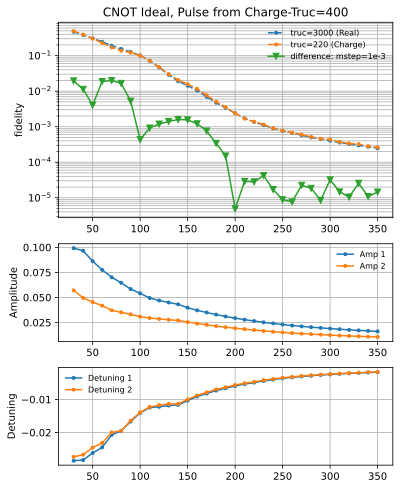

In [ ]:
a1 = -1
a2 = 1

fig, ax = plt.subplots(3,1,figsize=(6,8), gridspec_kw={'height_ratios': [2, 1, 1]})
ax[0].set_title(fr'CNOT Ideal, Pulse from Charge-Truc=400', fontsize=12)
ax[0].plot(tg_vec, 10**f_real[:,a1], '.--', label=f'truc={truc_real[a1]} (Real)')
ax[0].plot(tg_vec, 10**f_charge[:,a2], '.--', label=f'truc={truc_charge[a2]} (Charge)')
ax[0].plot(tg_vec, np.abs(10**f_charge[:,a2] - 10**f_real[:,a1]), 'v-',  label=r'difference: mstep=1e-3')
ax[0].set_ylabel('fidelity')
ax[0].set_yscale('log')
ax[0].legend(framealpha=0, fontsize=8)

ax[1].plot(params[:,0], params[:,1], '.-', label='Amp 1')
ax[1].plot(params[:,0], params[:,2], '.-', label='Amp 2')
ax[1].set_ylabel('Amplitude')
ax[1].legend(framealpha=0, fontsize=8)

ax[2].plot(params[:,0], params[:,3], '.-', label='Detuning 1')
ax[2].plot(params[:,0], params[:,4], '.-', label='Detuning 2')
ax[2].set_ylabel('Detuning')
ax[2].legend(framealpha=0, fontsize=8)
for a in ax:
    a.grid(which='both')
plt.savefig('result.png', dpi=300, bbox_inches='tight')

## Get the time used for each loop

In [ ]:
import time
N = 20

times = []
loop_idx = []

for i in range(N):
    t0 = time.perf_counter()

    # ====== 你原来的代码 ======
    time.sleep(0.05 + 0.01*i)   # 示例：假装计算越来越慢
    # =========================

    t1 = time.perf_counter()

    times.append(t1 - t0)
    loop_idx.append(i)

times = np.array(times)
loop_idx = np.array(loop_idx)


## Truncation-lowest & tg

In [15]:
f_tg_250_350 = np.array([
[-2.1158987700288114, -2.1554663160656564, -2.1799793721111524, -2.2154612392439117, -2.2595357150303736, -2.263799999530826, -2.3151861073412308, -2.347606049965283, -2.3543458691230934, -2.4017424616971867, -2.423009707465999] ,
[-2.1799872480919027, -2.2246523631846267, -2.2465155064841578, -2.2841041203666825, -2.328293210296099, -2.3321870843656645, -2.3857828168599355, -2.421919696016996, -2.4263968557188305, -2.4774413757876754, -2.496956669036164] ,
[-3.1149581062308522, -3.1701326645276433, -3.222494690328663, -3.2858761725805805, -3.3388748470215805, -3.3602277587017175, -3.427932367948772, -3.4725916935246555, -3.4904563288629595, -3.546507671165293, -3.582862133723935] ,
[-3.1214376599576457, -3.1757173915873027, -3.238671988614939, -3.301737392552384, -3.347692920342427, -3.3925546698111604, -3.4452688155211795, -3.48724561946553, -3.5256973911153913, -3.563191495964059, -3.607827912057003] ,
[-3.124491249673183, -3.1793008151485393, -3.24213986803063, -3.304717993352983, -3.3509069126421203, -3.394574247473349, -3.448215594265799, -3.4893717946060643, -3.5276720292896777, -3.5655693569284304, -3.6097544040398355] ,
[-3.1218884579461506, -3.1763448799769116, -3.240074061217664, -3.3023932718952596, -3.3476789293178744, -3.393766119670064, -3.4457561732302535, -3.486517373664902, -3.5271097638384754, -3.5633956073734785, -3.608143229047786] ,
[-3.1202481923727343, -3.175252418394964, -3.2393424016572667, -3.3017714871134465, -3.347051942158881, -3.3934024301798535, -3.445401042839633, -3.4863258138202236, -3.5262841477668423, -3.5632347016579287, -3.607548211243421] ,
])

f_tg_30_240 = np.array([
[-0.3267679312832743, -0.4109146577258421, -0.5314175721191159, -0.6565539019026647, -0.7869725703579956, -0.8725638772466902, -0.9643668882814288, -1.0430093061167198, -1.1827036778628164, -1.3186127996488501, -1.4776468419375939, -1.5387423728146796, -1.6067295859784336, -1.6789146966175532, -1.7810026964664216, -1.8429319254177443, -1.8623589270334047, -1.9238871980989352, -1.9647993984240832, -1.9659679500840601, -2.0080188298793034, -2.0670761416493755] ,
[-0.38538269771872946, -0.5166102219446712, -0.6468384133645357, -0.7581097991869837, -0.8281475347539664, -0.8594403826477517, -0.9203415557046127, -1.028073719046364, -1.2064676487704358, -1.3576785337299266, -1.517275355207493, -1.5602154570206648, -1.6196077384741214, -1.7029712352502893, -1.8198953185096214, -1.8868066009749858, -1.9115106351701605, -1.9794804816972495, -2.0258236817338777, -2.0282202505183626, -2.070724848770627, -2.1273712387660586] ,
[-0.31032858757337445, -0.4047033668923342, -0.5180138569579682, -0.642019008349195, -0.7627420447183272, -0.8573254771755296, -0.9123223561566713, -0.9961634846461208, -1.1388420997411781, -1.320844629297156, -1.5177843288943988, -1.6870207631041692, -1.8019851634025812, -1.9330449049065868, -2.113863216407559, -2.294559346163571, -2.4503216795173826, -2.6223485169837373, -2.7720501312133004, -2.8580875158708503, -2.9393032630998346, -3.0386774412465405] ,
[-0.31447341551830515, -0.41059872186388924, -0.5225140294206853, -0.6429654346712351, -0.7604103721793298, -0.8559455998265485, -0.9125111675248297, -0.9968528149597475, -1.1397190801913202, -1.3259296936881744, -1.5298368589942466, -1.7147161194447054, -1.8399911069415482, -1.9727591030688694, -2.150024192160583, -2.3185058489133255, -2.4690580019905712, -2.6233774296434325, -2.766315480376127, -2.8682385278277, -2.955509880047226, -3.048044898496971] ,
[-0.32093211980634323, -0.4082722578043336, -0.5147089293379499, -0.6278995094052177, -0.7404399363805648, -0.8356897333190908, -0.907906233694823, -1.0001445626712537, -1.146074017415794, -1.33407037739906, -1.5417907513400713, -1.7289813327444592, -1.8533166245205137, -1.9830525032659119, -2.157173571044143, -2.319493081072803, -2.4646950152531697, -2.6185199519727225, -2.762378303948839, -2.8643823508521775, -2.9556360793306924, -3.050068170265694] ,
[-0.32840925902117996, -0.41731492543344245, -0.5128486975398967, -0.611858755464256, -0.7218672974356771, -0.8144699681675194, -0.8974156042069967, -0.9970333787025316, -1.1463741688842977, -1.333830026276924, -1.5403412536399395, -1.7240930293601553, -1.8477792471858616, -1.9798893703628184, -2.1568060034772953, -2.321608017438526, -2.467531326971976, -2.6216068102226915, -2.7651545938034894, -2.8674343019998525, -2.956918333585929, -3.0488954089580074] ,
[-0.3283368071311917, -0.41740435064551973, -0.5124982001551515, -0.6100811093797481, -0.7184067932132072, -0.8111218490187576, -0.8952859271924165, -0.9947833456632321, -1.144336899640069, -1.3316158998329173, -1.537839806651908, -1.7215297683238566, -1.8466913398060316, -1.9801801590695682, -2.158210350092046, -2.3241107164216155, -2.468974638414638, -2.6213823197377404, -2.764662667931768, -2.8671667449036504, -2.9559693272724785, -3.0471478243322028] ,
])

f_truc_200_3000 = np.column_stack(( f_tg_30_240, f_tg_250_350))
print(np.shape(f_tg_250_350), np.shape(f_tg_30_240))
print(np.shape(f_truc_200_3000),)

(7, 11) (7, 22)
(7, 33)


In [68]:
fname = "data/fidelity_vs_real_truncation_and_tg.txt"

truc_vec = [200, 400, 600, 800, 1000, 2000, 3000]
data = np.loadtxt(fname, delimiter=",")
tg_vec = data[:, 0]
fidelity = data[:, 1:]   # shape: (Nt, Ntruc)

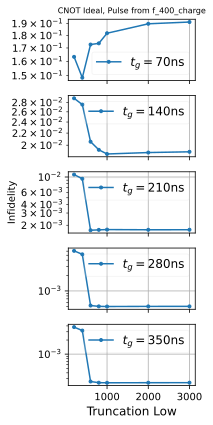

In [73]:
start = 1
tg_idx = np.arange(33)[4::7]

fig, ax = plt.subplots(5, 1, figsize=(3, 6), sharex=True)
for i, tg_i in enumerate(tg_idx):
    ax[i].plot(truc_vec, 10**fidelity[tg_i], '.-', label=fr"$t_g = {tg_vec[tg_i]:.0f}$ns")
    ax[i].set_yscale('log')
    ax[i].grid()
    legend = ax[i].legend(loc="best", fontsize=12)
    legend.get_frame().set_alpha(0.2)
ax[4].set_xlabel('Truncation Low', fontsize=12)
ax[0].set_title('CNOT Ideal, Pulse from f_400_charge', fontsize=8)
ax[2].set_ylabel(fr"Infidelity")
plt.tight_layout()
plt.savefig('result.png', dpi=300, bbox_inches='tight')

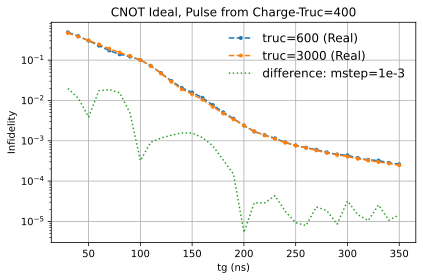

In [63]:
# tg_length = f_400_charge.shape[1]
a1 = 2
a2 = -1

fig, ax = plt.subplots(1,1,figsize=(6,4))
ax.set_title('CNOT from npz')
ax.plot(tg_vec, 10**fidelity[:,a1], '.--', label=f'truc={truc_vec[a1]} (Real)')
ax.plot(tg_vec, 10**fidelity[:,a2], '.--', label=f'truc={truc_vec[a2]} (Real)')

ax.plot(tg_vec, np.abs(10**fidelity[:,a2] - 10**fidelity[:,a1]), ':',  label=r'difference: mstep=1e-3')
ax.set_title(fr'CNOT Ideal, Pulse from Charge-Truc=400', fontsize=12)
ax.set_ylabel('Infidelity')
ax.set_xlabel('tg (ns)')
ax.set_yscale('log')
ax.legend(framealpha=0, fontsize=12)
ax.grid()
plt.tight_layout()
plt.savefig('result.png', dpi=300, bbox_inches='tight')

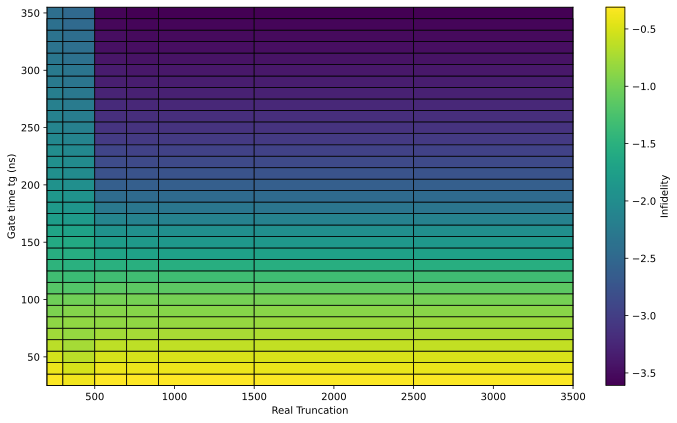

In [ ]:

# ---------- 构造 bin 边界 ----------
tg_edges = np.concatenate([
    tg_vec - (tg_vec[1] - tg_vec[0]) / 2,
    [tg_vec[-1] + (tg_vec[-1] - tg_vec[-2]) / 2]
])

truc_edges = np.concatenate([
    truc_vec - np.diff(truc_vec, prepend=truc_vec[0]) / 2,
    [truc_vec[-1] + (truc_vec[-1] - truc_vec[-2]) / 2]
])

# ---------- plot ----------
fig, ax = plt.subplots(figsize=(10, 6))

pcm = ax.pcolormesh(
    truc_edges,
    tg_edges,
    fidelity,
    shading="flat",
    edgecolors="k",      # 黑色边界
    linewidth=0.8        # 明显加粗
)

# ax.set_xticks(np.arange(len(truc_vec)))
# ax.set_xticklabels(truc_vec)

ax.set_xlabel("Real Truncation")
ax.set_ylabel("Gate time tg (ns)")

cbar = plt.colorbar(pcm, ax=ax)
cbar.set_label("Infidelity")

plt.tight_layout()
plt.savefig('result.png', dpi=300, bbox_inches='tight')

## Truncation-charge & tg

In [64]:
truc_vec = [200, 220, 240, 260, 280, 300, 320, 340, 360, 380, 400, 500, 600, 700, 800, 900]
f_tg_290_350 = np.array([
[-2.4633012851699294, -2.461543353905418, -2.517625620408961, -2.5538258206152027, -2.554041702986061, -2.6082271529238636, -2.625502944831999] ,
[-3.3389362823450477, -3.360396627375963, -3.4279914109150957, -3.472598128492253, -3.490480357018586, -3.5463630236308963, -3.5828143016223737] ,
[-3.3468400335960493, -3.391594655270802, -3.44426699098272, -3.4868240933763337, -3.5248124309856412, -3.5627574084592357, -3.6072266866257054] ,
[-3.3477665471874687, -3.3918638362460687, -3.4451513016760047, -3.487266399434118, -3.5250612749397248, -3.5632175401299433, -3.6076650484326374] ,
[-3.3480131260509474, -3.3921050837506717, -3.4453742080976197, -3.487463944222251, -3.5252684220922084, -3.563377254522193, -3.607821449776305] ,
[-3.35025301722399, -3.395023073850207, -3.4478214233878046, -3.489181144124733, -3.5280144284171535, -3.5652171303564084, -3.609752668306644] ,
[-3.350378677169039, -3.3949651916420382, -3.4479093733165587, -3.4892017556491983, -3.528029018669059, -3.5653439743297786, -3.609777471063193] ,
[-3.350811614344409, -3.3945041555092064, -3.4481136932480956, -3.4893152544422605, -3.5276274790038338, -3.5654375499278728, -3.6096950071829887] ,
[-3.3508648130142715, -3.394562483112327, -3.448164471231005, -3.4893289971820436, -3.527686464413984, -3.565493632615669, -3.609736489170812] ,
[-3.349873345439834, -3.393650941854013, -3.447212246335804, -3.488425819381058, -3.5268929227652643, -3.564670165716978, -3.6089843332721787] ,
[-3.3492767055065227, -3.3935056684495772, -3.446817654745852, -3.487925873362122, -3.5267632227291923, -3.564239687817917, -3.608700491311103] ,
])

f_tg_30_280 = np.array([
[-0.32996246455828215, -0.42841089094693435, -0.5449922622569213, -0.659430283739076, -0.7648053775265593, -0.8242699532411542, -0.8933990988590854, -0.9954891638925184, -1.1590133242782714, -1.3102667985392904, -1.4690728550450478, -1.5378038949188728, -1.599513912477293, -1.6912374524987892, -1.8260589271587397, -1.9309597756359436, -1.9893242142036187, -2.0879541461106386, -2.153542195407629, -2.1597707352409534, -2.2015299612191677, -2.263358691945115, -2.3166898943788343, -2.3608642450068498, -2.379954576277708, -2.418628471496865] ,
[-0.31068876875881146, -0.40474120680338427, -0.5182362555135999, -0.6446963954338235, -0.766131387194322, -0.860506919138273, -0.9136197265107322, -0.9966463628410708, -1.1388130886231325, -1.320690383585831, -1.5172810609920035, -1.6865200215748626, -1.8015598158453494, -1.932589445394398, -2.1131113510570354, -2.2940526692984355, -2.450177134102312, -2.622270869035448, -2.772039024462527, -2.8582994598989755, -2.9397797015039218, -3.038978355886757, -3.115224507419317, -3.170303806255576, -3.2227460076740635, -3.2860078364017156] ,
[-0.30967251432687076, -0.40321104950760045, -0.5156275229404947, -0.6392339161537759, -0.7594725221397695, -0.8557027932470678, -0.9105906033202994, -0.9937389353344221, -1.1359729459281862, -1.3215447482639004, -1.5246353439371447, -1.7098693771816231, -1.836303004505719, -1.9695521631965962, -2.1470412742754204, -2.315768558527745, -2.467125165104407, -2.621247333534015, -2.76459495107619, -2.867605485447596, -2.9536713236383534, -3.046569739192725, -3.119969903977422, -3.174189332701747, -3.2369913287253826, -3.3008107076915696] ,
[-0.3131935579636922, -0.4087253640359896, -0.5212816987506438, -0.644206551910019, -0.7636479120652517, -0.8590476231378661, -0.9137712174757437, -0.9972959122405063, -1.1399606916505238, -1.3261636874493887, -1.5300926798485055, -1.7150060441295847, -1.8404518359154218, -1.9734458967923187, -2.151169946139143, -2.3199352321174023, -2.4703461154950395, -2.6245314998822287, -2.7671109446904074, -2.8683158381632623, -2.9552073551771656, -3.0479381166176007, -3.121432843292193, -3.175719316597337, -3.238383769162584, -3.3015446569663247] ,
[-0.31359041760716316, -0.4090185534865361, -0.5215058975263844, -0.6442337762655878, -0.7633857560958474, -0.8587028416335857, -0.9137531870504157, -0.9974830659270717, -1.1402764622796966, -1.32654845408507, -1.530622574195963, -1.7154979614531676, -1.8408030302914293, -1.9738024592814432, -2.1516114123397743, -2.3202868419500065, -2.470574615232092, -2.6246952959268315, -2.7672527338472857, -2.868400222018095, -2.9553371018786914, -3.0481559202396267, -3.1216756039519074, -3.1759619751219654, -3.2386328771439836, -3.301797445798807] ,
[-0.32131676379720403, -0.41875043684210767, -0.52797956282902, -0.6448141912305718, -0.7600211113530949, -0.8553062566785014, -0.9138181462196683, -0.999028813163847, -1.1423417347142468, -1.3292822088294378, -1.5347247311536119, -1.7214241881205616, -1.8474043790836505, -1.97975067992401, -2.156407391881222, -2.3227552829648728, -2.4713440194725367, -2.6242206839427937, -2.766447603120845, -2.868471543934018, -2.957190422215708, -3.0501868185905194, -3.123818922500174, -3.1782296516733046, -3.2415554728151124, -3.304386840818906] ,
[-0.3233088053220827, -0.4211023351447931, -0.529968233669991, -0.6449572574780433, -0.7577970298889413, -0.8525789931406591, -0.9133755454336505, -0.9998919043133357, -1.1438540991168975, -1.331193086315407, -1.5374430030026822, -1.724748641157584, -1.8496186321950774, -1.9797919528349057, -2.153703036732576, -2.316982982419403, -2.46377657337819, -2.6171969039720824, -2.7609942992073226, -2.8645761222737964, -2.9555835242783957, -3.0496063293722186, -3.1237544177972083, -3.1784198005163926, -3.241691128108309, -3.304494978591446] ,
[-0.3229591586627027, -0.41104400852229445, -0.5167487022705817, -0.6290943044586708, -0.7404111898228769, -0.8350049107752286, -0.9072495846368495, -0.9999632324720329, -1.1463444085108925, -1.3345338932904378, -1.5423750260258606, -1.7295933253303912, -1.8540634596542895, -1.9843347293460774, -2.1591700774080076, -2.321860640556555, -2.4671466628663703, -2.620599255688432, -2.7632493433874123, -2.8647398079888036, -2.955699888949283, -3.0500668084850284, -3.1244345160264677, -3.1791911068820067, -3.2420337994041812, -3.3046394348236054] ,
[-0.32108838196007417, -0.40825348128975103, -0.5145319005276662, -0.6278642667802952, -0.7409997938460701, -0.8363017997874193, -0.9084422826209168, -1.0007675871269424, -1.146963036698251, -1.3353933324432128, -1.5439324157966512, -1.7322157001098273, -1.8573331980887593, -1.9871939093402076, -2.1612763087338145, -2.322145024539626, -2.466067288208454, -2.6186965882675146, -2.7617835266489927, -2.8632453102928204, -2.9550147693705116, -3.0497555699152183, -3.1243422402731036, -3.179172181864752, -3.2420613488855086, -3.304689894432557] ,
[-0.32418342720059096, -0.41188245824374814, -0.5180627805343083, -0.6306298407622632, -0.7422562285580822, -0.8366434453644336, -0.908069561185102, -1.0010698458887979, -1.1469775525754844, -1.3346998957136205, -1.542115812629451, -1.7289418289560163, -1.850839752652415, -1.9773339895241109, -2.1472036146245315, -2.3062778537767077, -2.4502606613981923, -2.605654929298348, -2.751815624417014, -2.856483995661336, -2.9516937020105267, -3.0478801224721086, -3.123130142394367, -3.178216885971366, -3.241113888598207, -3.303723425583314] ,
[-0.3229769040495751, -0.41025551544175026, -0.5165352011445101, -0.6297718707049131, -0.7421700008505105, -0.8367188196906097, -0.906192214595771, -0.9991764624075837, -1.1451811810269537, -1.33197150049731, -1.5370520870578197, -1.7193367541832116, -1.8464420821719705, -1.984145250998966, -2.169162499812074, -2.342126019737745, -2.491900769841267, -2.643168493818408, -2.780591789899089, -2.875742921372378, -2.9599669451784156, -3.0509345105094927, -3.1237171033023787, -3.177965920870775, -3.240891063238493, -3.3032751513167566] ,
])

print(np.shape(f_tg_290_350), np.shape(f_tg_30_280))
f_truc_200_400 = np.column_stack((f_tg_30_280, f_tg_290_350))

f_truc_500_900 = np.array([
[-0.3274662811462453, -0.4206851533263801, -0.522955876717642, -0.6259873230497832, -0.7268878520392216, -0.8178560728291928, -0.8982835233592761, -0.9970894289087356, -1.1443472840284683, -1.3310484366352788, -1.5360232160389604, -1.7187982375705673, -1.843308669451204, -1.9777551748603113, -2.158800148384533, -2.329909057231084, -2.4803298422327207, -2.6333916052438795, -2.773605282879396, -2.8724656063861485, -2.9588324793323113, -3.0497367074917547, -3.122343647573756, -3.176612376728241, -3.2402131780870973, -3.302536465909353, -3.3478127552280723, -3.3938640178205493, -3.445836001305397, -3.486627438193966, -3.52728032248591, -3.563286062222718, -3.608145958625275] ,
[-0.3334408089943819, -0.4299071470993625, -0.5314781240388597, -0.6326047212492064, -0.7314809736582975, -0.8205894648497948, -0.9011447741648396, -1.000765318295234, -1.1488813140811476, -1.3364581201956, -1.5432385956659593, -1.7265981329803208, -1.8498785475373494, -1.9832914822548597, -2.163666297581192, -2.332851748306346, -2.481369029759127, -2.63348304411808, -2.7733134406756506, -2.871653638014176, -2.958613711680885, -3.049677050407058, -3.1223644774250188, -3.1766319034090893, -3.240214633405069, -3.30246268098316, -3.347631266647079, -3.3939104090011996, -3.445667277198499, -3.4863544233836183, -3.5273471747571756, -3.563010748360395, -3.607971757906657] ,
[-0.3286093861122834, -0.41794884691977513, -0.5136069579338618, -0.6122636207862718, -0.7215316645372866, -0.8141497851983339, -0.8965563408226116, -0.9960604087498288, -1.1456993224727199, -1.3331126809524423, -1.5398549342535934, -1.723571698907984, -1.8480031934323018, -1.9807344350335925, -2.1586756355412344, -2.324068852692725, -2.4721485273224117, -2.6255979192817347, -2.7669701894108107, -2.868351375969873, -2.957100239193227, -3.0488429309156357, -3.1216199396310214, -3.175918848261609, -3.239817149055687, -3.302105001036472, -3.347129403585444, -3.3938451302542014, -3.445291147298204, -3.485931794974647, -3.527269337545325, -3.5626778059478026, -3.6077276147264037] ,
[-0.3285280818221642, -0.4177489862229034, -0.51337469004284, -0.6119482858495726, -0.7209558564353784, -0.8134419729179602, -0.8962433407606397, -0.9957112688564191, -1.1456453087196545, -1.3330530981328923, -1.5397519576995866, -1.723487214666621, -1.848049856448356, -1.9806266144345948, -2.1582804085911436, -2.3241584701341576, -2.4720993115355476, -2.6250475694317914, -2.766740732008772, -2.868371365181726, -2.957209828479703, -3.0487413764379663, -3.1214583714866966, -3.175718572260857, -3.2396899359402718, -3.30197457997589, -3.34696881197732, -3.393800667299712, -3.4451573672991955, -3.485735896309548, -3.5272066245538265, -3.5625744834770856, -3.6076462991375253] ,
[-0.32794894973275046, -0.4170931928047215, -0.5126872334854696, -0.6113163440801134, -0.719941719434582, -0.8123489095425978, -0.8953872961909667, -0.9949302439013723, -1.1447270990752396, -1.332021187890384, -1.538476051325964, -1.7223163138231306, -1.8472012573323033, -1.9800653741336236, -2.1575819549261928, -2.3238623581157176, -2.4722100100999924, -2.6237516988421055, -2.766099335659097, -2.868250014841193, -2.95713865179204, -3.048577844818163, -3.1212043401053178, -3.1754444361760195, -3.239563534761169, -3.3018480085963926, -3.346779389159713, -3.393820168463125, -3.4450242099405632, -3.4855929508410237, -3.5271946630670463, -3.5624720820338043, -3.607594071452594] ,
])
# np.shape(f_truc_500_900)

f_truc_200_900 = np.row_stack((f_truc_200_400, f_truc_500_900))
print(np.shape(f_truc_200_900))

(11, 7) (11, 26)
(16, 33)


In [65]:
# tg_vec = np.arange(30, 351, 10)
# data_out = np.column_stack([tg_vec, np.round(f_truc_200_900.T, 8)])

# header = (
#     "# first column: gate time tg (ns)\n"
#     "# other columns: truncation\n"
#     "# tg(ns), " +
#     " ".join([f"{truc}," for truc in truc_vec])
# )

# np.savetxt(
#     "data/fidelity_vs_charge_picked_truncation_and_tg.txt",
#     data_out,
#     fmt="%.8f",
#     delimiter=",",
#     header=header,
#     comments=""
# )


In [ ]:
fname = "data/fidelity_vs_charge_picked_truncation_and_tg.txt"

data = np.loadtxt(fname, delimiter=",")
tg_vec = data[:, 0]
fidelity = data[:, 1:]   # shape: (Nt, Ntruc)

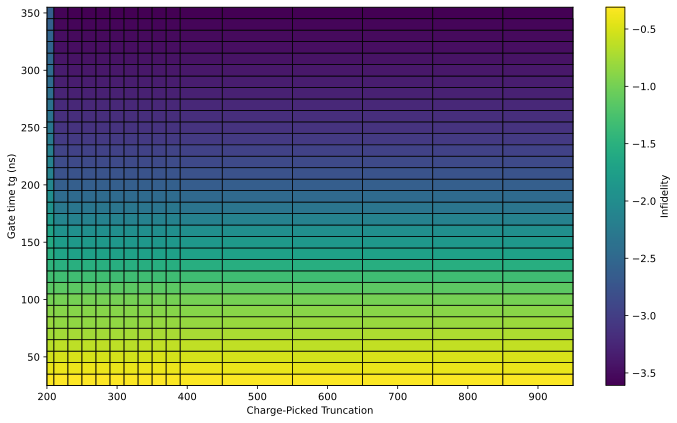

In [ ]:
# ---------- 构造 bin 边界 ----------
tg_edges = np.concatenate([
    tg_vec - (tg_vec[1] - tg_vec[0]) / 2,
    [tg_vec[-1] + (tg_vec[-1] - tg_vec[-2]) / 2]
])

truc_edges = np.concatenate([
    truc_vec - np.diff(truc_vec, prepend=truc_vec[0]) / 2,
    [truc_vec[-1] + (truc_vec[-1] - truc_vec[-2]) / 2]
])

# ---------- plot ----------
fig, ax = plt.subplots(figsize=(10, 6))

pcm = ax.pcolormesh(
    truc_edges,
    tg_edges,
    fidelity,
    shading="flat",
    edgecolors="k",      # 黑色边界
    linewidth=0.8        # 明显加粗
)

# truc_vec = np.array([200, 220, 240, 260, 280, 300, 320, 340,
#                       360, 380, 400, 500, 600, 700, 800, 900])

# ax.set_xticks(np.arange(len(truc_vec)))
# ax.set_xticklabels(truc_vec)

ax.set_xlabel("Charge-Picked Truncation")
ax.set_ylabel("Gate time tg (ns)")

cbar = plt.colorbar(pcm, ax=ax)
cbar.set_label("Infidelity")

plt.tight_layout()
plt.savefig('result.png', dpi=300, bbox_inches='tight')

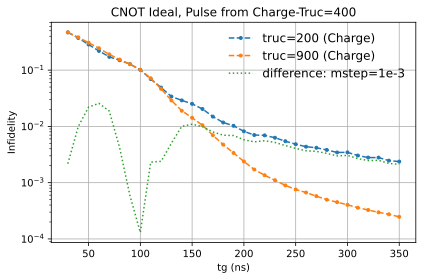

In [21]:
# tg_length = f_400_charge.shape[1]
a1 = 0
a2 = 15

fig, ax = plt.subplots(1,1,figsize=(6,4))
ax.set_title('CNOT from npz')
ax.plot(cnot['tg'], 10**f_truc_200_900[a1], '.--', label=f'truc={truc_vec[a1]} (Charge)')
ax.plot(cnot['tg'], 10**f_truc_200_900[a2], '.--', label=f'truc={truc_vec[a2]} (Charge)')

ax.plot(cnot['tg'], np.abs(10**f_truc_200_900[a2] - 10**f_truc_200_900[a1]), ':',  label=r'difference: mstep=1e-3')
ax.set_title(fr'CNOT Ideal, Pulse from Charge-Truc=400', fontsize=12)
ax.set_ylabel('Infidelity')
ax.set_xlabel('tg (ns)')
ax.set_yscale('log')
ax.legend(framealpha=0, fontsize=12)
ax.grid()
plt.tight_layout()
plt.savefig('result.png', dpi=300, bbox_inches='tight')

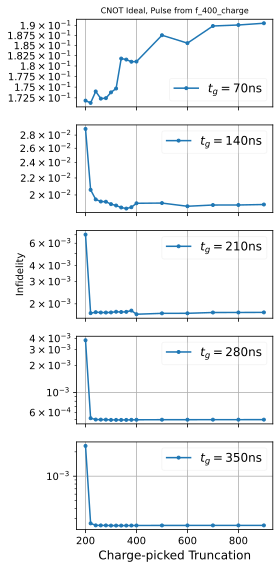

In [29]:
start = 1
tg_idx = np.arange(33)[4::7]

fig, ax = plt.subplots(5, 1, figsize=(4, 8), sharex=True)
for i, tg_i in enumerate(tg_idx):
    ax[i].plot(truc_vec, 10**f_truc_200_900[:,tg_i], '.-', label=fr"$t_g = {cnot['tg'][tg_i]:.0f}$ns")
    ax[i].set_yscale('log')
    ax[i].grid()
    legend = ax[i].legend(loc="best", fontsize=12)
    legend.get_frame().set_alpha(0.2)
ax[4].set_xlabel('Charge-picked Truncation', fontsize=12)
ax[0].set_title('CNOT Ideal, Pulse from f_400_charge', fontsize=8)
ax[2].set_ylabel(fr"Infidelity")
plt.tight_layout()
plt.savefig('result.png', dpi=300, bbox_inches='tight')

## Infidelity vs tg or truncation

In [23]:
truc_vec = [200, 400, 600, 800, 1000, 2000, 3000]

f_600 = np.array([
[-0.31994460121918317, -0.4049726472882984, -0.5126010093750809, -0.6411314730519762, -0.7817236989556011, -0.8862851541622216, -0.9447644086014441, -1.0396535458927847, -1.1589506367466988, -1.3609164431469654, -1.4509088357770679, -1.563361696898237, -1.621792149789588, -1.7215065998851655, -1.827843943240959, -1.8954801569422512] ,
[-0.3734483074823763, -0.5123988911695672, -0.6340575268605262, -0.7411705273298408, -0.8344305271525416, -0.8730787061599578, -0.8924989809571684, -1.0218751562914747, -1.1758667159934144, -1.402501763212032, -1.49487789513994, -1.580229825807402, -1.6351132807384259, -1.742749126142079, -1.862788766091244, -1.9443409432388103] ,
[-0.3120874580234073, -0.4056310818134501, -0.5206085485946128, -0.6460483109589936, -0.7673292226867283, -0.8599855481597405, -0.9144330415522715, -0.9952911907225543, -1.1386546037997147, -1.3203583042182192, -1.5166848329104987, -1.6874255442999635, -1.804352890996658, -1.9397200130333956, -2.119701953175892, -2.297602475781647] ,
[-0.3154436850503642, -0.4113441932751899, -0.524369574285491, -0.6459495671507345, -0.7643389491730921, -0.8574665419427243, -0.9147339311792418, -0.9962291931007714, -1.1406789896555884, -1.3227210191060499, -1.5306013208516498, -1.7132503552613385, -1.8423450123637515, -1.9700997593362375, -2.140613018712041, -2.3067521530695285] ,
[-0.3201055295892338, -0.4078782625727294, -0.5113763056810161, -0.6258690096780815, -0.7365770434107208, -0.8320923724888956, -0.9038868572298727, -0.9989625609473076, -1.1461593338180998, -1.3321504759732123, -1.541703386493474, -1.7276849007184378, -1.8570921331582273, -1.980009839738305, -2.1470293262137847, -2.308780640697684] ,
[-0.3264258999775012, -0.4168073673179859, -0.508491356100646, -0.6080314192351584, -0.7087315576959885, -0.8073390973133026, -0.8885341423453327, -0.9949004871809745, -1.145699364091858, -1.333139631152764, -1.5393661295813454, -1.7234094041811168, -1.8512961344111722, -1.9779793198102174, -2.1473319544693803, -2.310359252546742] ,
[-0.3262558969028171, -0.4168210621284251, -0.5078282024280932, -0.6057121534188715, -0.7049664772281262, -0.8034119719959432, -0.8860311971563785, -0.9926582475045647, -1.1435124471985252, -1.3308085251115322, -1.537047643019397, -1.7210553885738773, -1.849951236508359, -1.9780924094551426, -2.1483206004894844, -2.312475491166789] ,
])

f_400_charge = np.array([
[-0.3267679312832743, -0.4109146577258421, -0.5314175721191159, -0.6565539019026647, -0.7869725703579956, -0.8725638772466902, -0.9643668882814288, -1.0430093061167198, -1.1827036778628164, -1.3186127996488501, -1.4776468419375939, -1.5387423728146796, -1.6067295859784336, -1.6789146966175532, -1.7810026964664216, -1.8429319254177443, -1.8623589270334047, -1.9238871980989352, -1.9647993984240832, -1.9659679500840601, -2.0080188298793034, -2.0670761416493755] ,
[-0.38538269771872946, -0.5166102219446712, -0.6468384133645357, -0.7581097991869837, -0.8281475347539664, -0.8594403826477517, -0.9203415557046127, -1.028073719046364, -1.2064676487704358, -1.3576785337299266, -1.517275355207493, -1.5602154570206648, -1.6196077384741214, -1.7029712352502893, -1.8198953185096214, -1.8868066009749858, -1.9115106351701605, -1.9794804816972495, -2.0258236817338777, -2.0282202505183626, -2.070724848770627, -2.1273712387660586] ,
[-0.31032858757337445, -0.4047033668923342, -0.5180138569579682, -0.642019008349195, -0.7627420447183272, -0.8573254771755296, -0.9123223561566713, -0.9961634846461208, -1.1388420997411781, -1.320844629297156, -1.5177843288943988, -1.6870207631041692, -1.8019851634025812, -1.9330449049065868, -2.113863216407559, -2.294559346163571, -2.4503216795173826, -2.6223485169837373, -2.7720501312133004, -2.8580875158708503, -2.9393032630998346, -3.0386774412465405] ,
[-0.31447341551830515, -0.41059872186388924, -0.5225140294206853, -0.6429654346712351, -0.7604103721793298, -0.8559455998265485, -0.9125111675248297, -0.9968528149597475, -1.1397190801913202, -1.3259296936881744, -1.5298368589942466, -1.7147161194447054, -1.8399911069415482, -1.9727591030688694, -2.150024192160583, -2.3185058489133255, -2.4690580019905712, -2.6233774296434325, -2.766315480376127, -2.8682385278277, -2.955509880047226, -3.048044898496971] ,
[-0.32093211980634323, -0.4082722578043336, -0.5147089293379499, -0.6278995094052177, -0.7404399363805648, -0.8356897333190908, -0.907906233694823, -1.0001445626712537, -1.146074017415794, -1.33407037739906, -1.5417907513400713, -1.7289813327444592, -1.8533166245205137, -1.9830525032659119, -2.157173571044143, -2.319493081072803, -2.4646950152531697, -2.6185199519727225, -2.762378303948839, -2.8643823508521775, -2.9556360793306924, -3.050068170265694] ,
[-0.32840925902117996, -0.41731492543344245, -0.5128486975398967, -0.611858755464256, -0.7218672974356771, -0.8144699681675194, -0.8974156042069967, -0.9970333787025316, -1.1463741688842977, -1.333830026276924, -1.5403412536399395, -1.7240930293601553, -1.8477792471858616, -1.9798893703628184, -2.1568060034772953, -2.321608017438526, -2.467531326971976, -2.6216068102226915, -2.7651545938034894, -2.8674343019998525, -2.956918333585929, -3.0488954089580074] ,
[-0.3283368071311917, -0.41740435064551973, -0.5124982001551515, -0.6100811093797481, -0.7184067932132072, -0.8111218490187576, -0.8952859271924165, -0.9947833456632321, -1.144336899640069, -1.3316158998329173, -1.537839806651908, -1.7215297683238566, -1.8466913398060316, -1.9801801590695682, -2.158210350092046, -2.3241107164216155, -2.468974638414638, -2.6213823197377404, -2.764662667931768, -2.8671667449036504, -2.9559693272724785, -3.0471478243322028] ,
])

print(np.shape(f_600), np.shape(f_400_charge))
print(np.arange(16)[::3])

(7, 16) (7, 22)
[ 0  3  6  9 12 15]


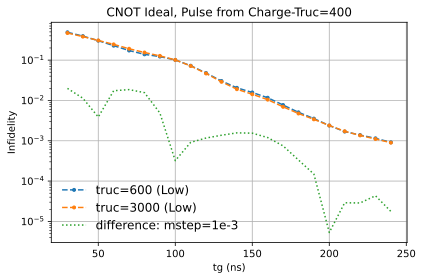

In [26]:
tg_length = f_400_charge.shape[1]

fig, ax = plt.subplots(1,1,figsize=(6,4))
ax.set_title('CNOT from npz')
ax.plot(cnot['tg'][:tg_length], 10**f_400_charge[2], '.--', label='truc=600 (Low)')
ax.plot(cnot['tg'][:tg_length], 10**f_400_charge[6], '.--', label='truc=3000 (Low)')

ax.plot(cnot['tg'][:tg_length], np.abs(10**f_400_charge[2] - 10**f_400_charge[6]), ':',  label=r'difference: mstep=1e-3')
ax.set_title(fr'CNOT Ideal, Pulse from Charge-Truc=400', fontsize=12)
ax.set_ylabel('Infidelity')
ax.set_xlabel('tg (ns)')
ax.set_yscale('log')
ax.legend(framealpha=0, fontsize=12)
ax.grid()
plt.tight_layout()
plt.savefig('result.png', dpi=300, bbox_inches='tight')

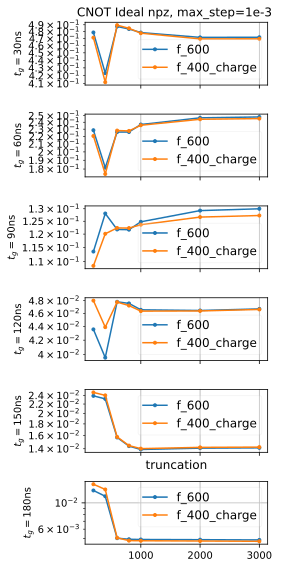

In [15]:
start = 1
tg_idx = np.arange(16)[::3]

fig, ax = plt.subplots(6, 1, figsize=(4, 8), sharex=True)
for i, tg_i in enumerate(tg_idx):
    ax[i].plot(truc_vec, 10**f_600[:,tg_i], '.-', label="f_600")
    ax[i].plot(truc_vec, 10**f_400_charge[:,tg_i], '.-', label="f_400_charge")
    ax[i].set_yscale('log')
    ax[i].set_ylabel(fr"$t_g = {cnot['tg'][tg_i]:.0f}$ns")
    ax[i].grid()
    legend = ax[i].legend(loc="best", fontsize=12)
    legend.get_frame().set_alpha(0.2)
ax[4].set_xlabel('truncation', fontsize=12)
ax[0].set_title(fr'CNOT Ideal npz, max_step=1e-3 ', fontsize=12)
plt.tight_layout()

## Charge-Picked Truncation

In [2]:
truc_vec = np.arange(200, 401, step=20)
tg_vec = np.arange(30, 281, step=10)
f_400_charge_v2 = np.array([
[-0.32996246455828215, -0.42841089094693435, -0.5449922622569213, -0.659430283739076, -0.7648053775265593, -0.8242699532411542, -0.8933990988590854, -0.9954891638925184, -1.1590133242782714, -1.3102667985392904, -1.4690728550450478, -1.5378038949188728, -1.599513912477293, -1.6912374524987892, -1.8260589271587397, -1.9309597756359436, -1.9893242142036187, -2.0879541461106386, -2.153542195407629, -2.1597707352409534, -2.2015299612191677, -2.263358691945115, -2.3166898943788343, -2.3608642450068498, -2.379954576277708, -2.418628471496865] ,
[-0.31068876875881146, -0.40474120680338427, -0.5182362555135999, -0.6446963954338235, -0.766131387194322, -0.860506919138273, -0.9136197265107322, -0.9966463628410708, -1.1388130886231325, -1.320690383585831, -1.5172810609920035, -1.6865200215748626, -1.8015598158453494, -1.932589445394398, -2.1131113510570354, -2.2940526692984355, -2.450177134102312, -2.622270869035448, -2.772039024462527, -2.8582994598989755, -2.9397797015039218, -3.038978355886757, -3.115224507419317, -3.170303806255576, -3.2227460076740635, -3.2860078364017156] ,
[-0.30967251432687076, -0.40321104950760045, -0.5156275229404947, -0.6392339161537759, -0.7594725221397695, -0.8557027932470678, -0.9105906033202994, -0.9937389353344221, -1.1359729459281862, -1.3215447482639004, -1.5246353439371447, -1.7098693771816231, -1.836303004505719, -1.9695521631965962, -2.1470412742754204, -2.315768558527745, -2.467125165104407, -2.621247333534015, -2.76459495107619, -2.867605485447596, -2.9536713236383534, -3.046569739192725, -3.119969903977422, -3.174189332701747, -3.2369913287253826, -3.3008107076915696] ,
[-0.3131935579636922, -0.4087253640359896, -0.5212816987506438, -0.644206551910019, -0.7636479120652517, -0.8590476231378661, -0.9137712174757437, -0.9972959122405063, -1.1399606916505238, -1.3261636874493887, -1.5300926798485055, -1.7150060441295847, -1.8404518359154218, -1.9734458967923187, -2.151169946139143, -2.3199352321174023, -2.4703461154950395, -2.6245314998822287, -2.7671109446904074, -2.8683158381632623, -2.9552073551771656, -3.0479381166176007, -3.121432843292193, -3.175719316597337, -3.238383769162584, -3.3015446569663247] ,
[-0.31359041760716316, -0.4090185534865361, -0.5215058975263844, -0.6442337762655878, -0.7633857560958474, -0.8587028416335857, -0.9137531870504157, -0.9974830659270717, -1.1402764622796966, -1.32654845408507, -1.530622574195963, -1.7154979614531676, -1.8408030302914293, -1.9738024592814432, -2.1516114123397743, -2.3202868419500065, -2.470574615232092, -2.6246952959268315, -2.7672527338472857, -2.868400222018095, -2.9553371018786914, -3.0481559202396267, -3.1216756039519074, -3.1759619751219654, -3.2386328771439836, -3.301797445798807] ,
[-0.32131676379720403, -0.41875043684210767, -0.52797956282902, -0.6448141912305718, -0.7600211113530949, -0.8553062566785014, -0.9138181462196683, -0.999028813163847, -1.1423417347142468, -1.3292822088294378, -1.5347247311536119, -1.7214241881205616, -1.8474043790836505, -1.97975067992401, -2.156407391881222, -2.3227552829648728, -2.4713440194725367, -2.6242206839427937, -2.766447603120845, -2.868471543934018, -2.957190422215708, -3.0501868185905194, -3.123818922500174, -3.1782296516733046, -3.2415554728151124, -3.304386840818906] ,
[-0.3233088053220827, -0.4211023351447931, -0.529968233669991, -0.6449572574780433, -0.7577970298889413, -0.8525789931406591, -0.9133755454336505, -0.9998919043133357, -1.1438540991168975, -1.331193086315407, -1.5374430030026822, -1.724748641157584, -1.8496186321950774, -1.9797919528349057, -2.153703036732576, -2.316982982419403, -2.46377657337819, -2.6171969039720824, -2.7609942992073226, -2.8645761222737964, -2.9555835242783957, -3.0496063293722186, -3.1237544177972083, -3.1784198005163926, -3.241691128108309, -3.304494978591446] ,
[-0.3229591586627027, -0.41104400852229445, -0.5167487022705817, -0.6290943044586708, -0.7404111898228769, -0.8350049107752286, -0.9072495846368495, -0.9999632324720329, -1.1463444085108925, -1.3345338932904378, -1.5423750260258606, -1.7295933253303912, -1.8540634596542895, -1.9843347293460774, -2.1591700774080076, -2.321860640556555, -2.4671466628663703, -2.620599255688432, -2.7632493433874123, -2.8647398079888036, -2.955699888949283, -3.0500668084850284, -3.1244345160264677, -3.1791911068820067, -3.2420337994041812, -3.3046394348236054] ,
[-0.32108838196007417, -0.40825348128975103, -0.5145319005276662, -0.6278642667802952, -0.7409997938460701, -0.8363017997874193, -0.9084422826209168, -1.0007675871269424, -1.146963036698251, -1.3353933324432128, -1.5439324157966512, -1.7322157001098273, -1.8573331980887593, -1.9871939093402076, -2.1612763087338145, -2.322145024539626, -2.466067288208454, -2.6186965882675146, -2.7617835266489927, -2.8632453102928204, -2.9550147693705116, -3.0497555699152183, -3.1243422402731036, -3.179172181864752, -3.2420613488855086, -3.304689894432557] ,
[-0.32418342720059096, -0.41188245824374814, -0.5180627805343083, -0.6306298407622632, -0.7422562285580822, -0.8366434453644336, -0.908069561185102, -1.0010698458887979, -1.1469775525754844, -1.3346998957136205, -1.542115812629451, -1.7289418289560163, -1.850839752652415, -1.9773339895241109, -2.1472036146245315, -2.3062778537767077, -2.4502606613981923, -2.605654929298348, -2.751815624417014, -2.856483995661336, -2.9516937020105267, -3.0478801224721086, -3.123130142394367, -3.178216885971366, -3.241113888598207, -3.303723425583314] ,
[-0.3229769040495751, -0.41025551544175026, -0.5165352011445101, -0.6297718707049131, -0.7421700008505105, -0.8367188196906097, -0.906192214595771, -0.9991764624075837, -1.1451811810269537, -1.33197150049731, -1.5370520870578197, -1.7193367541832116, -1.8464420821719705, -1.984145250998966, -2.169162499812074, -2.342126019737745, -2.491900769841267, -2.643168493818408, -2.780591789899089, -2.875742921372378, -2.9599669451784156, -3.0509345105094927, -3.1237171033023787, -3.177965920870775, -3.240891063238493, -3.3032751513167566] ,
])

print(np.shape(f_400_charge_v2))
print(len(truc_vec), len(tg_vec))
print(np.arange(26)[::5])

(11, 26)
11 26
[ 0  5 10 15 20 25]


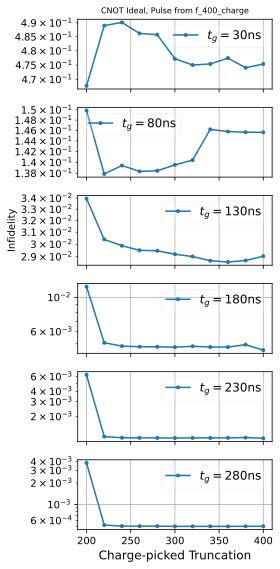

In [3]:
start = 1
tg_idx = np.arange(26)[::5]

fig, ax = plt.subplots(6, 1, figsize=(4, 8), sharex=True)
for i, tg_i in enumerate(tg_idx):
    ax[i].plot(truc_vec, 10**f_400_charge_v2[:,tg_i], '.-', label=fr"$t_g = {cnot['tg'][tg_i]:.0f}$ns")
    ax[i].set_yscale('log')
    ax[i].grid()
    legend = ax[i].legend(loc="best", fontsize=12)
    legend.get_frame().set_alpha(0.2)
ax[5].set_xlabel('Charge-picked Truncation', fontsize=12)
ax[0].set_title('CNOT Ideal, Pulse from f_400_charge', fontsize=8)
ax[2].set_ylabel(fr"Infidelity")
plt.tight_layout()
plt.savefig('result.png', dpi=300, bbox_inches='tight')

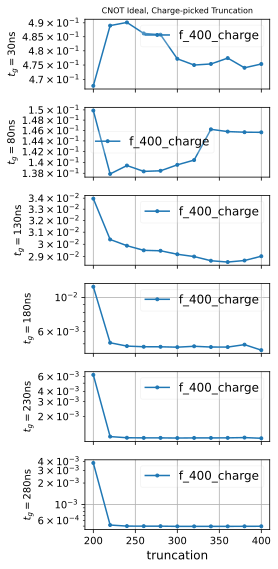

In [ ]:
start = 1
tg_idx = np.arange(26)[::5]

fig, ax = plt.subplots(6, 1, figsize=(4, 8), sharex=True)
for i, tg_i in enumerate(tg_idx):
    ax[i].plot(truc_vec, 10**f_400_charge_v2[:,tg_i], '.-', label="f_400_charge")
    ax[i].set_yscale('log')
    ax[i].set_ylabel(fr"$t_g = {cnot['tg'][tg_i]:.0f}$ns")
    ax[i].grid()
    legend = ax[i].legend(loc="best", fontsize=12)
    legend.get_frame().set_alpha(0.2)
ax[5].set_xlabel('truncation', fontsize=12)
ax[0].set_title(fr'CNOT Ideal, Charge-picked Truncation', fontsize=8)
plt.tight_layout()

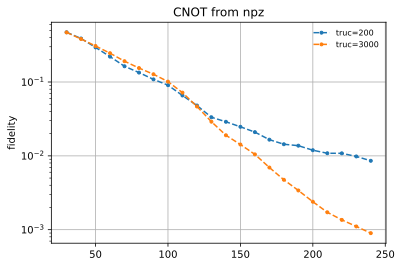

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(6,4))
ax.set_title('CNOT from npz')
# ax.plot(cnot['tg'][:22], 10**f_400_charge[0], '.--', label='truc=200')
# ax.plot(cnot['tg'][:22], 10**f_400_charge[2], '.--', label='truc=600')
# ax.plot(cnot['tg'][:22], 10**f_400_charge[6], '.--', label='truc=3000')

# ax.plot(cnot['tg'], np.abs(10**fidelity_list[3] - 10**fidelity_list[8]), ':',  label=r'difference: mstep=1e-3')
ax.set_ylabel('fidelity')
ax.set_yscale('log')
ax.legend(framealpha=0, fontsize=8)
ax.grid()

In [ ]:
f_400_charge

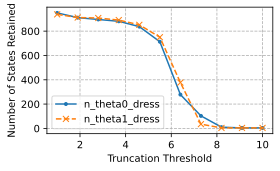

In [83]:
# thresh_vec = np.logspace(-8, 1, 10)
# thresh_vec = np.logspace(-7, -6.9, 10)
# thresh_vec = np.logspace(0, 1, 10)
thresh_vec = np.linspace(1, 10, 11)
truc_vec0 = []
truc_vec1 = []

for thresh in thresh_vec:
    truc_vec0.append(len(trunc_by_thresh(logi_idx, n_theta0_dress, thresh=thresh)))
    truc_vec1.append(len(trunc_by_thresh(logi_idx, n_theta1_dress, thresh=thresh)))

plt.figure(figsize=(4,2.5))
plt.plot(thresh_vec, truc_vec0, '.-', label='n_theta0_dress')
plt.plot(thresh_vec, truc_vec1, 'x--', label='n_theta1_dress')
# plt.xscale('log')
# plt.yscale('log')
plt.xlabel('Truncation Threshold')
plt.ylabel('Number of States Retained')
plt.legend()
plt.grid(which='both', ls='--')
plt.tight_layout()
plt.savefig('result.png', dpi=300, bbox_inches='tight')

In [82]:
# n_theta1_dress
print(f'thresh_vec={thresh_vec.tolist()}')
print(f'truc_vec0={truc_vec0}')
print(f'truc_vec1={truc_vec1}')

thresh_vec=[0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6000000000000001, 0.7000000000000001, 0.8, 0.9, 1.0]
truc_vec0=[3000, 966, 966, 966, 966, 966, 965, 965, 958, 958, 950]
truc_vec1=[3000, 966, 966, 966, 962, 958, 952, 952, 947, 941, 938]


In [ ]:
# n_theta1_dress
thresh_vec = [1.0, 1.2915496650148839, 1.6681005372000588, 2.154434690031884, 2.7825594022071245, 3.5938136638046276, 4.641588833612778, 5.994842503189409, 7.742636826811269, 10.0]
truc_vec0 = [938, 927, 921, 911, 908, 894, 848, 523, 26, 4]

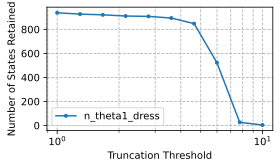

In [ ]:
plt.figure(figsize=(4,2.5))
plt.plot(thresh_vec, truc_vec0, '.-', label='n_theta1_dress')
plt.xscale('log')
# plt.yscale('log')
plt.xlabel('Truncation Threshold')
plt.ylabel('Number of States Retained')
plt.legend()
plt.grid(which='both', ls='--')
plt.tight_layout()
plt.savefig('result.png', dpi=300, bbox_inches='tight')

In [46]:
thresh = 5
h_tot_0_truc_idx = trunc_by_thresh(logi_idx, n_theta1_dress, thresh=thresh)
print(f'thresh = {thresh}')
print(f'len(h_tot_0_truc_idx) = {len(h_tot_0_truc_idx)}')

thresh = 5
len(h_tot_0_truc_idx) = 816


In [31]:
thresh = 1e-1
h_tot_0_truc_idx = trunc_by_thresh(logi_idx, n_theta1_dress, thresh=thresh)
print(f'thresh = {thresh}')
print(f'len(h_tot_0_truc_idx) = {len(h_tot_0_truc_idx)}')

thresh = 0.1
len(h_tot_0_truc_idx) = 966


In [32]:
thresh = 1e-8
h_tot_0_truc_idx = trunc_by_thresh(logi_idx, n_theta1_dress, thresh=thresh)
print(f'thresh = {thresh}')
print(f'len(h_tot_0_truc_idx) = {len(h_tot_0_truc_idx)}')

thresh = 1e-08
len(h_tot_0_truc_idx) = 3000


In [25]:
print(len(h_tot_0_truc_idx))
print(h_tot_0_truc_idx[:20])
h_tot_0_truc = np.array(hspace_full)[h_tot_0_truc_idx]
print(h_tot_0_truc[:20])


966
[0, 1, 2, 3, 5, 7, 8, 9, 10, 12, 14, 16, 20, 21, 25, 26, 27, 28, 31, 33]
['0-0' '0-1' '1-0' '0-2' '2-0' '0-4' '4-0' '1-1' '0-5' '2-1' '5-0' '1-2'
 '0-8' '2-2' '8-0' '1-4' '4-1' '0-9' '2-4' '9-0']


In [2]:
folder_load='../../data/_truc_3000'
(hspace_full, eket_tot, eval_tot, _,
    n_theta1_dress, hspace_0, hspace_1, logi_state) = hd.load_two_qubit_data(
    folder_load, return_full=False
)
print(hspace_full[:20])
print(eval_tot[:20])

['0-0', '0-1', '1-0', '0-3', '0-2', '2-0', '3-0', '0-4', '4-0', '1-1', '0-5', '0-6', '2-1', '3-1', '5-0', '6-0', '1-2', '1-3', '0-7', '7-0']
[-83.83378269 -68.69262676 -67.52123553 -62.40017255 -62.40836136
 -62.19822546 -62.19422189 -54.3131255  -52.72462905 -51.8039306
 -47.7026708  -47.64717433 -47.10182983 -47.09453049 -46.20636098
 -46.18431159 -46.13191534 -46.1202957  -44.78997274 -42.54184307]


In [16]:
print(f'len(hspace_0): {len(hspace_0)}')
print(f'len(hspace_1): {len(hspace_1)}')
# print(f'hspace_0: {hspace_0}')
# print(f'hspace_1: {hspace_1}')

len(hspace_0): 154
len(hspace_1): 155


In [ ]:
f_ideal_200_1e3 = np.array([
-0.34405913, -0.45084231, -0.58883554, -0.74771256 ,
-0.90003982, -0.99674315, -1.02708895, -1.12621283 ,
-1.31129811, -1.55278492, -1.82527647, -2.03192752 ,
-2.16442008, -2.34113331, -2.52357653, -2.64505317 ,
-2.74555521, -2.85613517, -2.94185662, -3.00968804 ,
-3.08409924, -3.15526938, -3.21100254, -3.26403995 ,
-3.32667737, -3.36404764, -3.41085180, -3.45784316 ,
-3.50390315, -3.54396933, -3.56970975, -3.61208189 ,
-3.65150720 ,
])
f_ideal_200_1e4 = np.array([
-0.34406235, -0.45084970, -0.58884824, -0.74772713 ,
-0.90003602, -0.99669771, -1.02701294, -1.12617631 ,
-1.31130620, -1.55283639, -1.82534048, -2.03195453 ,
-2.16444062, -2.34119450, -2.52368605, -2.64515626 ,
-2.74570833, -2.85636245, -2.94205831, -3.00975767 ,
-3.08435806, -3.15525635, -3.21110205, -3.26422424 ,
-3.32674601, -3.36422184, -3.41090748, -3.45821715 ,
-3.50450203, -3.54402354, -3.56866855, -3.61239541 ,
-3.65087953 ,
])

f_ideal_1000 = np.array([
-0.28757185, -0.35310882, -0.42669454, -0.53264771 ,
-0.61319175, -0.69332214, -0.83418931, -0.90466221 ,
-0.99279080, -1.14644828, -1.26706741, -1.37588605 ,
-1.45964429, -1.55600151, -1.65040157, -1.71760448 ,
-1.77646385, -1.84968403, -1.90523700, -1.95600266 ,
-1.99768000, -2.07417918, -2.10412022, -2.12389748 ,
-2.17040487, -2.21130816, -2.24415089, -2.26340491 ,
-2.28378356, -2.34103944, -2.37352642, -2.38245235 ,
-2.42670614 ,
])
truc_vec0 = np.arange(200, 1001, 100)
fidelity_list = np.array([
[-0.34405913210863326, -0.4508423100132303, -0.5888355429780345, -0.7477125626529988, -0.900039819030078, -0.9967431450964658, -1.0270889471394282, -1.126212826640297, -1.311298105992371, -1.552784922582532, -1.825276472390432, -2.0319275189277155, -2.16442008358229, -2.341133309167501, -2.523576526554056, -2.645053171114868, -2.7455552065367743, -2.856135166846176, -2.9418566243990596, -3.009688037051578, -3.084099242079128, -3.155269381314999, -3.211002540868915, -3.2640399450488125, -3.326677369000708, -3.364047635759781, -3.410851800894313, -3.4578431572744215, -3.503903154478879, -3.5439693347458214, -3.56970974880652, -3.612081893259896, -3.6515071953351304] ,
[-0.3735877520294146, -0.49842178212718535, -0.634194639429704, -0.7714847704482062, -0.8637959221589534, -0.9004423994653843, -0.9573133154530379, -1.1215256995070082, -1.3145880210919993, -1.5465494485637739, -1.7609743308689976, -1.9042552898018203, -2.0200778398548693, -2.180678650661939, -2.32671963918194, -2.4192071570147227, -2.502796785973527, -2.599719744746896, -2.676787951742799, -2.7490954116423874, -2.8113451895165946, -2.9071513795631136, -2.954873345957708, -2.995949075666405, -3.0663419356539543, -3.116322047113821, -3.1683104362861783, -3.2033885143540286, -3.240475492262842, -3.319170942790408, -3.3727653752856455, -3.3845842093278256, -3.4561938501270877] ,
[-0.3780649356175367, -0.5077640700718318, -0.6533998645313485, -0.804253069184494, -0.9009590465658563, -0.9321380999865108, -0.9888759771308536, -1.1644388691644916, -1.3720874537740755, -1.632489298861436, -1.8640341579092483, -2.012577442307184, -2.1348517658978388, -2.3163573342687505, -2.474268052581571, -2.5737460957992115, -2.661601461519809, -2.7630831387464374, -2.837897066400709, -2.909961217721723, -2.9676299661828494, -3.0671951816474983, -3.1124902446641194, -3.1508165784730164, -3.218396517553413, -3.2624809483561172, -3.3124462623590083, -3.341969986976396, -3.380861191778336, -3.453219987371566, -3.496839256608997, -3.5087942552457565, -3.578322686515368] ,
[-0.3095757833550014, -0.3632780370348222, -0.4625687778670863, -0.613661468427612, -0.7419482056687134, -0.8372495801945267, -0.9415460343156901, -1.0958137132554413, -1.2796106943187093, -1.5242443193614408, -1.7468605424532313, -1.9182464459895516, -2.04698449075841, -2.225350556983136, -2.393703347211968, -2.4844544785956226, -2.5624711651390535, -2.6707929808859894, -2.744437255012491, -2.810061367076849, -2.8694900804355594, -2.980919296480901, -3.0072409339361093, -3.02295964145681, -3.0963031541519297, -3.1330710152681815, -3.1772106570545513, -3.2050722094756696, -3.2235116616738364, -3.3073912151568616, -3.3535429142554634, -3.3504398432913476, -3.4155942288596477] ,
[-0.2675716629391375, -0.3329021269003556, -0.4072632076723954, -0.5184662203651295, -0.6226885344927778, -0.7275551103529438, -0.8389115206866135, -0.9006970515880857, -0.989203677206519, -1.1419930006436048, -1.2615450049417904, -1.3714422102825716, -1.4670769971196247, -1.5753192815195762, -1.679610256384796, -1.7540712829982623, -1.81621949163297, -1.8921851400074154, -1.9491346570462964, -2.0009759653557273, -2.043743574002872, -2.122895543922747, -2.1530631856666185, -2.1725927155089497, -2.2205685280643506, -2.26222488751469, -2.2957325031440665, -2.315158859623836, -2.3354720689856734, -2.3947093458090025, -2.427797877000753, -2.436255268746418, -2.4817848281125143] ,
[-0.2698612388605307, -0.33715894128105994, -0.4116561851597083, -0.5211428265338519, -0.6227483203675813, -0.7255639541628025, -0.8363035480453852, -0.8951258468386636, -0.9807735206754014, -1.1321180800039923, -1.2513817396145643, -1.3605763468528609, -1.448617352556292, -1.5479360864950067, -1.6443946153267648, -1.7127271770621637, -1.7720209603604016, -1.8455510342692432, -1.901496691365038, -1.9526627096001055, -1.994905719435338, -2.071727878469365, -2.1021627640919336, -2.1223685587939505, -2.1692348355946676, -2.2104935929135565, -2.2436237468206364, -2.2631968309439414, -2.283830242145683, -2.3413274648194724, -2.373986851671573, -2.3831843503274075, -2.4276034263786426] ,
[-0.27352109841231115, -0.34174669801502777, -0.41738099485874325, -0.5252733377240182, -0.6210014538687781, -0.719295686046042, -0.8350174444503857, -0.8951161831269964, -0.9808509490061438, -1.1321829321641124, -1.2512897848487583, -1.3603211558189812, -1.4481577208524261, -1.547306270872675, -1.6435723278504784, -1.7117629354389952, -1.7709554023728078, -1.8443831096145167, -1.900244274736873, -1.95134589668824, -1.99352521462119, -2.070237110723626, -2.1006433670307207, -2.120832435947181, -2.167632487673511, -2.208841429092309, -2.241928670659573, -2.261475762026241, -2.282090575199787, -2.3395012359207588, -2.37212881582, -2.3813205483817326, -2.42568154147431] ,
[-0.28488639950027433, -0.35886087182073034, -0.4346354889038455, -0.5387618460144631, -0.62604496262309, -0.7157767561459254, -0.8374913545116602, -0.900420920983297, -0.986711337046669, -1.1387902494211886, -1.258405407351766, -1.3670513482373687, -1.4521332741980264, -1.5492912634320934, -1.644379540528638, -1.7124231974011157, -1.7719219825648982, -1.845546989577661, -1.9015068575645637, -1.9526054749121449, -1.9946152663017425, -2.0712563001784003, -2.101492995054658, -2.1215405054218452, -2.1682073255607497, -2.209287333620807, -2.2422804871533804, -2.261707685601928, -2.2822336382016375, -2.339561067661376, -2.3721515620127698, -2.3812216736187857, -2.4255321908253977] ,
[-0.28757185171626704, -0.353108824548243, -0.42669454413945995, -0.5326477068060937, -0.6131917509213332, -0.6933221372944026, -0.834189314411494, -0.9046622082658861, -0.9927908004927872, -1.1464482766127935, -1.2670674050798763, -1.3758860535311, -1.459644293641959, -1.556001511071811, -1.6504015714769884, -1.7176044765433474, -1.7764638521954124, -1.8496840320716907, -1.905236998566126, -1.9560026553922318, -1.997680003885848, -2.0741791798905798, -2.104120220336066, -2.1238974833506123, -2.170404870251518, -2.211308161667524, -2.244150888320095, -2.2634049066418687, -2.283783559629952, -2.341039439776361, -2.373526424193921, -2.382452346870289, -2.426706142465435] ,
])

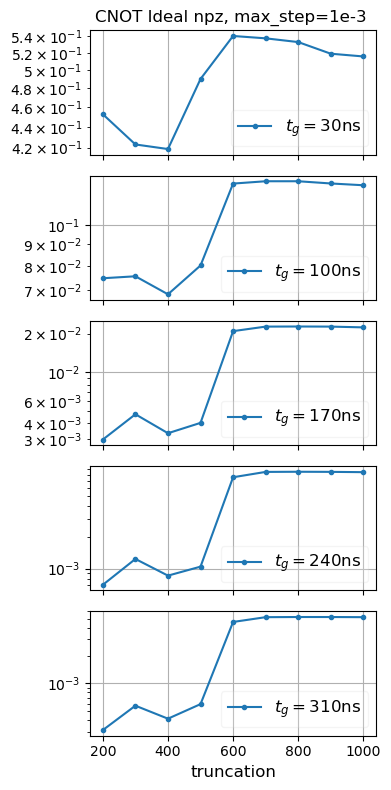

In [ ]:
start = 1
tg_idx = np.arange(33)[::7]

fig, ax = plt.subplots(5, 1, figsize=(4, 8), sharex=True)
for i, tg_i in enumerate(tg_idx):
    # ax[i].plot(truc_vec, 10**fidelity_list[:,tg_i], '.-')
    ax[i].plot(truc_vec0, 10**fidelity_list[:,tg_i], '.-', label=fr"$t_g = {cnot['tg'][tg_i]:.0f}$ns")
    # ax[i].axhline(y=10**f_true_2000[39,i+1], linestyle='--', color='red')
    ax[i].set_yscale('log')
    ax[i].grid()
    legend = ax[i].legend(loc="best", fontsize=12)
    legend.get_frame().set_alpha(0.2)
ax[4].set_xlabel('truncation', fontsize=12)
ax[0].set_title(fr'CNOT Ideal npz, max_step=1e-3 ', fontsize=12)
plt.tight_layout()

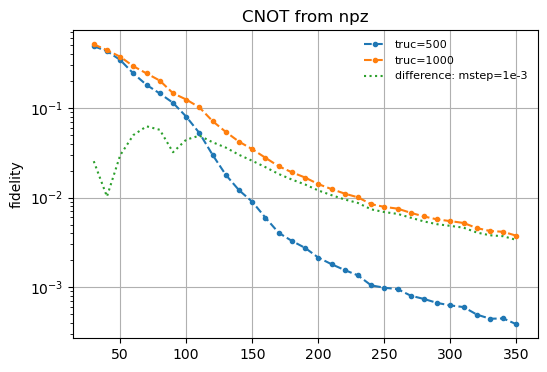

In [41]:
fig, ax = plt.subplots(1,1,figsize=(6,4))
ax.set_title('CNOT from npz')
# ax.plot(cnot['tg'], 10**fidelity_list[0], '.--', label='truc=200')
# ax.plot(cnot['tg'], 10**fidelity_list[4], '.--', label='truc=600')
ax.plot(cnot['tg'], 10**fidelity_list[3], '.--', label='truc=500')
ax.plot(cnot['tg'], 10**fidelity_list[8], '.--', label='truc=1000')

ax.plot(cnot['tg'], np.abs(10**fidelity_list[3] - 10**fidelity_list[8]), ':',  label=r'difference: mstep=1e-3')
ax.set_ylabel('fidelity')
ax.set_yscale('log')
ax.legend(framealpha=0, fontsize=8)
ax.grid()

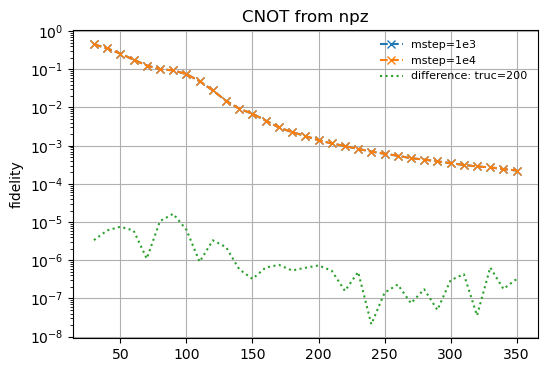

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(6,4))
ax.set_title('CNOT from npz')
# ax.plot(cnot['tg'], 10**cnot['f_200_1e3'], '.-', label='optimize: truc=200')
# ax.plot(cnot['tg'], 10**cnot['f_1000_1e3'], '.-', label='optimize: truc=1000', alpha=0.9)

ax.plot(cnot['tg'], 10**f_ideal_200_1e3, 'x--', label='mstep=1e3')
ax.plot(cnot['tg'], 10**f_ideal_200_1e4, 'x--', label='mstep=1e4')
# ax.plot(cnot['tg'], 10**f_ideal_1000, 'x--', label='check: truc=1000', alpha=0.9)

ax.plot(cnot['tg'], np.abs(10**f_ideal_200_1e4 - 10**f_ideal_200_1e3), ':',  label=r'difference: truc=200')
# ax.plot(cnot['tg'], np.abs(10**cnot['f_200_1e3'] - 10**f_ideal_200_1e3), ':',  label=r'difference: truc=200')
ax.set_ylabel('fidelity')
ax.set_yscale('log')
ax.legend(framealpha=0, fontsize=8)
ax.grid()

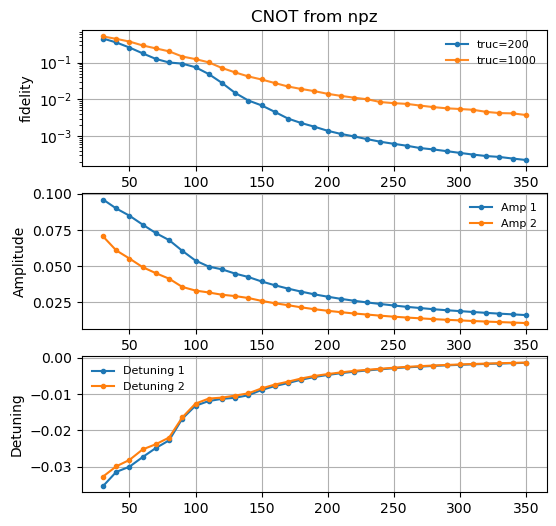

In [ ]:
fig, ax = plt.subplots(3,1,figsize=(6,6))
ax[0].set_title('CNOT from npz')
ax[0].plot(cnot['tg'], 10**cnot['f_200_1e3'], '.-', label='truc=200')
ax[0].plot(cnot['tg'], 10**cnot['f_1000_1e3'], '.-', label='truc=1000', alpha=0.9)
ax[0].set_ylabel('fidelity')
ax[0].set_yscale('log')
ax[0].legend(framealpha=0, fontsize=8)

ax[1].plot(cnot['tg'], cnot['drive_amp_1'], '.-', label='Amp 1')
ax[1].plot(cnot['tg'], cnot['drive_amp_2'], '.-', label='Amp 2')
ax[1].set_ylabel('Amplitude')
ax[1].legend(framealpha=0, fontsize=8)

ax[2].plot(cnot['tg'], cnot['detune_1'], '.-', label='Detuning 1')
ax[2].plot(cnot['tg'], cnot['detune_2'], '.-', label='Detuning 2')
ax[2].set_ylabel('Detuning')
ax[2].legend(framealpha=0, fontsize=8)
for a in ax:
    a.grid()

In [ ]:

param_optimized = np.array([
[170.00546, 0.034366, 0.022866, -0.006999, -0.006626] ,
[160.003744, 0.036697, 0.024228, -0.007844, -0.007419] ,
[149.998717, 0.039313, 0.025856, -0.008901, -0.00847] ,
[140.004488, 0.042401, 0.027835, -0.01035, -0.009827] ,
[129.990987, 0.044763, 0.029178, -0.011049, -0.010452] ,
[120.006244, 0.047722, 0.030113, -0.011343, -0.011007] ,
[110.000851, 0.049619, 0.031682, -0.011951, -0.011267] ,
[99.994847, 0.053799, 0.033004, -0.013238, -0.012653] ,
[89.99452, 0.060557, 0.035515, -0.016801, -0.016452] ,
[79.995939, 0.06799, 0.041242, -0.022761, -0.02199] ,
[70.005539, 0.072844, 0.045047, -0.024855, -0.023813] ,
[59.991291, 0.078729, 0.049231, -0.027353, -0.025249] ,
[50.004446, 0.084902, 0.055217, -0.030001, -0.028142] ,
[39.990704, 0.089924, 0.060848, -0.031439, -0.029904] ,
[29.998501, 0.096133, 0.070563, -0.035335, -0.032721] ,

[179.991194, 0.032266, 0.021367, -0.006084, -0.005751] ,
[190.000833, 0.03037, 0.020081, -0.005341, -0.005051] ,
[199.995462, 0.02876, 0.018994, -0.004778, -0.004543] ,
[209.997892, 0.027263, 0.018019, -0.004294, -0.004078] ,
[219.999949, 0.025936, 0.017113, -0.003877, -0.003663] ,
[230.000464, 0.024749, 0.016366, -0.003532, -0.003351] ,
[240.009843, 0.023687, 0.015583, -0.003224, -0.003064] ,
[250.006585, 0.022653, 0.014896, -0.002929, -0.002787] ,
[259.99859, 0.02171, 0.01429, -0.002681, -0.002542] ,
[269.998229, 0.020902, 0.013757, -0.002492, -0.002362] ,
[279.994844, 0.020071, 0.01321, -0.002289, -0.00218] ,
[290.008653, 0.019378, 0.012734, -0.002129, -0.002024] ,
[300.00454, 0.018764, 0.012331, -0.001994, -0.001895] ,
[309.992362, 0.018145, 0.011899, -0.001851, -0.001758] ,
[320.00381, 0.017545, 0.011503, -0.001738, -0.001654] ,
[330.003474, 0.016996, 0.011162, -0.001645, -0.00155] ,
[339.999982, 0.016511, 0.010823, -0.001535, -0.001458] ,
[350.005101, 0.016006, 0.010485, -0.001446, -0.00137] ,
])

f_200 = np.array([
 -2.52357408 ,
-2.34113577, -2.16442641, -2.03192739, -1.82527395 ,
-1.55278031, -1.31130084, -1.12621287, -1.02708850 ,
-0.99674259, -0.90003921, -0.74771374, -0.58883613 ,
-0.45084258, -0.34405894 ,

-2.64505754, -2.74560543, -2.85609492, -2.94193259 ,
-3.00974161, -3.08422837, -3.15532032, -3.21088366 ,
-3.26397628, -3.32672003, -3.36422371, -3.41062159 ,
-3.45788533, -3.50416466, -3.54403312, -3.56859996 ,
-3.61216283, -3.65160343 ,
])

f_1000 = np.array([
-1.65032653 ,
-1.55594077, -1.45961469, -1.37592826, -1.26701148 ,
-1.14649206, -0.99281778, -0.90463420, -0.83416392 ,
-0.69333521, -0.61318941, -0.53265813, -0.42669871 ,
-0.35311075, -0.28757017 ,

-1.71780311, -1.77680220, -1.84964923, -1.90524615 ,
-1.95570556, -1.99797891, -2.07406985, -2.10382287 ,
-2.12388023, -2.16972921, -2.21159196, -2.24421044 ,
-2.26308163, -2.28427353, -2.34097250, -2.37402150 ,
-2.38216372, -2.42632458 ,
])
A = np.column_stack((param_optimized, f_200, f_1000))
A_sorted = A[np.argsort(A[:, 0])]
for i in A_sorted:
    print(i.tolist(), ',')
    
df = pd.DataFrame(data=A_sorted,
                  columns=['tg', 'drive_amp_1', 'drive_amp_2', 'detune_1', 
                           'detune_2', 'f_200_1e3', 'f_1000_1e3'])

# df.to_csv('data/cnot_fidelity_npz---.txt', sep=',', index=False, header=True)    

[29.998501, 0.096133, 0.070563, -0.035335, -0.032721, -0.34405894, -0.28757017] ,
[39.990704, 0.089924, 0.060848, -0.031439, -0.029904, -0.45084258, -0.35311075] ,
[50.004446, 0.084902, 0.055217, -0.030001, -0.028142, -0.58883613, -0.42669871] ,
[59.991291, 0.078729, 0.049231, -0.027353, -0.025249, -0.74771374, -0.53265813] ,
[70.005539, 0.072844, 0.045047, -0.024855, -0.023813, -0.90003921, -0.61318941] ,
[79.995939, 0.06799, 0.041242, -0.022761, -0.02199, -0.99674259, -0.69333521] ,
[89.99452, 0.060557, 0.035515, -0.016801, -0.016452, -1.0270885, -0.83416392] ,
[99.994847, 0.053799, 0.033004, -0.013238, -0.012653, -1.12621287, -0.9046342] ,
[110.000851, 0.049619, 0.031682, -0.011951, -0.011267, -1.31130084, -0.99281778] ,
[120.006244, 0.047722, 0.030113, -0.011343, -0.011007, -1.55278031, -1.14649206] ,
[129.990987, 0.044763, 0.029178, -0.011049, -0.010452, -1.82527395, -1.26701148] ,
[140.004488, 0.042401, 0.027835, -0.01035, -0.009827, -2.03192739, -1.37592826] ,
[149.998717, 0.039

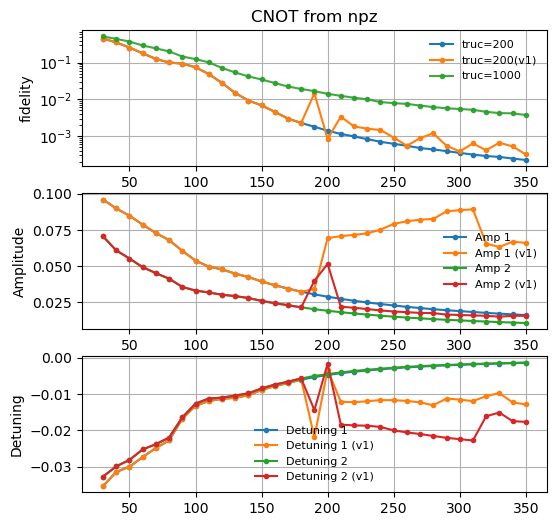

In [ ]:
fig, ax = plt.subplots(3,1,figsize=(6,6))
ax[0].set_title('CNOT from npz')
ax[0].plot(A_sorted[:,0], 10**A_sorted[:,-2], '.-', label='truc=200')
# ax[0].plot(A_sorted[:,0], 10**A_sorted_1[:,-2], '.-', label='truc=200(v1)')
ax[0].plot(A_sorted[:,0], 10**A_sorted[:,-1], '.-', label='truc=1000', alpha=0.9)
ax[0].set_ylabel('fidelity')
ax[0].set_yscale('log')
ax[0].legend(framealpha=0, fontsize=8)

ax[1].plot(A_sorted[:,0], A_sorted[:,1], '.-', label='Amp 1')
# ax[1].plot(A_sorted_1[:,0], A_sorted_1[:,1], '.-', label='Amp 1 (v1)')
ax[1].plot(A_sorted[:,0], A_sorted[:,2], '.-', label='Amp 2')
# ax[1].plot(A_sorted_1[:,0], A_sorted_1[:,2], '.-', label='Amp 2 (v1)')
ax[1].set_ylabel('Amplitude')
ax[1].legend(framealpha=0, fontsize=8)

ax[2].plot(A_sorted[:,0], A_sorted[:,3], '.-', label='Detuning 1')
# ax[2].plot(A_sorted_1[:,0], A_sorted_1[:,3], '.-', label='Detuning 1 (v1)')
ax[2].plot(A_sorted[:,0], A_sorted[:,4], '.-', label='Detuning 2')
# ax[2].plot(A_sorted_1[:,0], A_sorted_1[:,4], '.-', label='Detuning 2 (v1)')
ax[2].set_ylabel('Detuning')
ax[2].legend(framealpha=0, fontsize=8)
for a in ax:
    a.grid()

In [2]:
f_true_2000 = np.array([
[50.0, -0.26429282, -0.43713196, -0.33346741, -0.40395186, -0.56406677] ,
[100.0, -0.56083498, -1.39756588, -2.06654575, -2.32358149, -2.53558644] ,
[150.0, -0.68832975, -1.44331735, -2.07135286, -2.33649479, -2.54997386] ,
[200.0, -0.57375237, -1.40051849, -2.11258544, -2.38484624, -2.59734758] ,
[250.0, -0.52239618, -1.34613069, -2.52950154, -3.12089878, -3.45281184] ,
[300.0, -0.53243597, -1.3502951, -2.53254044, -3.12167042, -3.45260693] ,
[350.0, -0.50358979, -1.35416318, -2.53820257, -3.12292448, -3.45276155] ,
[400.0, -0.48786732, -1.32156795, -2.52929222, -3.12182423, -3.45203114] ,
[450.0, -0.48556427, -1.31462711, -2.5213821, -3.12120482, -3.45169124] ,
[500.0, -0.4986559, -1.31465354, -2.52158788, -3.12079239, -3.45132927] ,
[550.0, -0.49792592, -1.31151973, -2.5169221, -3.12069758, -3.45125532] ,
[600.0, -0.50349002, -1.29723708, -2.4569114, -3.12069797, -3.45104067] ,
[650.0, -0.50199364, -1.27034361, -2.0512982, -2.79553216, -3.40809315] ,
[700.0, -0.50325194, -1.27166301, -2.0707022, -2.80884293, -3.40613756] ,
[750.0, -0.50426364, -1.27323431, -2.07106566, -2.81420508, -3.4045628] ,
[800.0, -0.50466697, -1.27377939, -2.06128957, -2.82039293, -3.40273174] ,
[850.0, -0.50440723, -1.27430271, -2.05239012, -2.82339862, -3.40307723] ,
[900.0, -0.50434535, -1.27701143, -2.0548789, -2.82042437, -3.4059963] ,
[950.0, -0.49376323, -1.27837803, -2.05513981, -2.81793046, -3.40613685] ,
[1000.0, -0.48115027, -1.28213378, -2.04860114, -2.81334661, -3.40296554] ,
[1050.0, -0.48614277, -1.28469273, -2.07579978, -2.81230286, -3.39872296] ,
[1100.0, -0.4858179, -1.28419484, -2.07748702, -2.81773848, -3.39665693] ,
[1150.0, -0.48612394, -1.28321411, -2.08144085, -2.82179938, -3.40645792] ,
[1200.0, -0.48604851, -1.28313079, -2.08047216, -2.82277752, -3.40876486] ,
[1250.0, -0.48329911, -1.28223246, -2.0838994, -2.82270143, -3.40908001] ,
[1300.0, -0.48311892, -1.28244044, -2.08433615, -2.82105311, -3.40905832] ,
[1350.0, -0.48289485, -1.28294111, -2.08489776, -2.81856136, -3.40802931] ,
[1400.0, -0.48320466, -1.28459309, -2.08770095, -2.81301569, -3.40691666] ,
[1450.0, -0.4829036, -1.28473453, -2.08788451, -2.81165036, -3.40626207] ,
[1500.0, -0.48297261, -1.29431902, -2.10982431, -2.74271623, -3.38955391] ,
[1550.0, -0.48046568, -1.29077612, -2.22946461, -3.07972691, -3.24550857] ,
[1600.0, -0.48177074, -1.29124274, -2.2259668, -3.0788348, -3.24474766] ,
[1650.0, -0.48434952, -1.28982102, -2.22875078, -3.07886168, -3.24428657] ,
[1700.0, -0.48492975, -1.2897533, -2.22747655, -3.07830743, -3.24386183] ,
[1750.0, -0.48497041, -1.28797059, -2.22167955, -3.08623566, -3.26168259] ,
[1800.0, -0.48491026, -1.28760584, -2.2196649, -3.08639846, -3.26277502] ,
[1850.0, -0.48488857, -1.28741779, -2.21887169, -3.08637364, -3.26152034] ,
[1900.0, -0.48465338, -1.28720159, -2.21775867, -3.08616298, -3.26249268] ,
[1950.0, -0.48449906, -1.2863512, -2.21193439, -3.08799365, -3.27331283] ,
[2000.0, -0.48424708, -1.28583843, -2.21265742, -3.08759869, -3.27118325] ,
])


In [3]:
f_short_1000 = np.array([
[50.0, -0.32577914, -1.26966399, -2.16963011, -2.65338464, -2.93337925] ,
[100.0, -0.56514971, -1.35627212, -2.54326336, -3.12640385, -3.45341975] ,
[150.0, -0.54319622, -1.35281648, -2.53648541, -3.12366763, -3.45309583] ,
[200.0, -0.50595307, -1.31194575, -2.30281061, -3.1230125, -3.45240773] ,
[250.0, -0.51472785, -1.31066163, -2.29849745, -3.12136529, -3.45155976] ,
[300.0, -0.51042574, -1.3138066, -2.29735467, -3.12127531, -3.45150947] ,
[350.0, -0.49062384, -1.27826133, -2.05807051, -2.75771638, -3.39529248] ,
[400.0, -0.48041146, -1.28017653, -2.05291876, -2.76649632, -3.4105198] ,
[450.0, -0.48199719, -1.28086489, -2.05482744, -2.73767175, -3.41208928] ,
[500.0, -0.48097933, -1.28132694, -2.05401437, -2.71738049, -3.41015653] ,
[550.0, -0.48114654, -1.28222489, -2.05556241, -2.7510335, -3.41279171] ,
[600.0, -0.48108792, -1.28226211, -2.05452414, -2.76622365, -3.41172853] ,
[650.0, -0.48111943, -1.28206783, -2.05325371, -2.77153814, -3.4100562] ,
[700.0, -0.4811628, -1.28207402, -2.0525638, -2.77376594, -3.40935976] ,
[750.0, -0.48118117, -1.28212457, -2.04868818, -2.7774316, -3.40875148] ,
[800.0, -0.48116381, -1.28205078, -2.04293916, -2.78168777, -3.40883194] ,
[850.0, -0.48116256, -1.28206929, -2.0393677, -2.79103085, -3.40859195] ,
[900.0, -0.48116007, -1.28204105, -2.04106148, -2.80145638, -3.40853927] ,
[950.0, -0.48115651, -1.28209453, -2.0460742, -2.80757145, -3.40727442] ,
[1000.0, -0.48115027, -1.28213378, -2.04860114, -2.81334661, -3.40296554] ,
])

In [4]:
f_false_2000 = np.array([
[200.0, -0.53803983, -1.39654384, -2.06783962, -2.32418683, -2.53606318] ,
[250.0, -0.56927657, -1.39804688, -2.04556639, -2.30966084, -2.5252756] ,
[300.0, -0.66204804, -1.43080876, -2.11355747, -2.38542577, -2.60079478] ,
[350.0, -0.67708406, -1.44025902, -2.10097296, -2.36697642, -2.58009525] ,
[400.0, -0.68659745, -1.44380584, -2.07151026, -2.33653488, -2.55028492] ,
[450.0, -0.68652834, -1.44402268, -2.06704952, -2.33087873, -2.5441997] ,
[500.0, -0.56843866, -1.40266251, -2.1023475, -2.37701067, -2.59165649] ,
[550.0, -0.54051473, -1.37902754, -2.56658943, -3.11804748, -3.43058957] ,
[600.0, -0.52774266, -1.36116288, -2.55293216, -3.12208666, -3.44146482] ,
[650.0, -0.52136599, -1.34560233, -2.52907506, -3.12072916, -3.45269437] ,
[700.0, -0.52549365, -1.34846788, -2.53156166, -3.12171146, -3.45307568] ,
[750.0, -0.5262248, -1.35044209, -2.53315059, -3.12213434, -3.45315332] ,
[800.0, -0.52878476, -1.3497191, -2.5322391, -3.1216916, -3.45291846] ,
[850.0, -0.53308675, -1.35079307, -2.53334316, -3.12198447, -3.45272284] ,
[900.0, -0.53442687, -1.35082468, -2.53337028, -3.12183162, -3.45256955] ,
[950.0, -0.50350993, -1.35386181, -2.53824223, -3.12300678, -3.45289625] ,
[1000.0, -0.50227775, -1.35283884, -2.53816226, -3.12298396, -3.45287783] ,
[1050.0, -0.50371261, -1.35297502, -2.53827858, -3.12310184, -3.45293511] ,
[1100.0, -0.49558279, -1.33940808, -2.53872483, -3.12203596, -3.45235077] ,
[1150.0, -0.48781396, -1.32206948, -2.52887652, -3.12187668, -3.45221213] ,
[1200.0, -0.48760591, -1.322162, -2.5287019, -3.12193491, -3.45226149] ,
[1250.0, -0.4873598, -1.32163748, -2.52794436, -3.12174225, -3.45218406] ,
[1300.0, -0.4853948, -1.31532671, -2.52085139, -3.12137981, -3.45199901] ,
[1350.0, -0.48535959, -1.3153539, -2.52117798, -3.12138982, -3.45202121] ,
[1400.0, -0.48603144, -1.31488296, -2.5201227, -3.12081262, -3.45169491] ,
[1450.0, -0.49844049, -1.31529512, -2.52121582, -3.1209687, -3.45168287] ,
[1500.0, -0.49831789, -1.3154471, -2.52126342, -3.12096704, -3.45170283] ,
[1550.0, -0.49819416, -1.3154924, -2.52123601, -3.12092879, -3.45169036] ,
[1600.0, -0.49787548, -1.31397621, -2.51911184, -3.1209025, -3.45167913] ,
[1650.0, -0.49801017, -1.31193207, -2.51622667, -3.12053967, -3.45144478] ,
[1700.0, -0.49811429, -1.31193568, -2.51619683, -3.12052244, -3.45144509] ,
[1750.0, -0.50009191, -1.31003606, -2.51031545, -3.12030605, -3.45129594] ,
[1800.0, -0.49793914, -1.25432963, -2.13506068, -2.79555118, -3.39454211] ,
[1850.0, -0.49921264, -1.25689779, -2.14319231, -2.814213, -3.38952342] ,
[1900.0, -0.49868461, -1.25671934, -2.14186338, -2.80514513, -3.38901687] ,
[1950.0, -0.50344716, -1.26927655, -2.05327222, -2.80163764, -3.38806788] ,
[2000.0, -0.50066858, -1.26796851, -2.06082966, -2.79894949, -3.3881155] ,
])

In [5]:
np.where(f_short_1000[:,0] == 200)

(array([3]),)

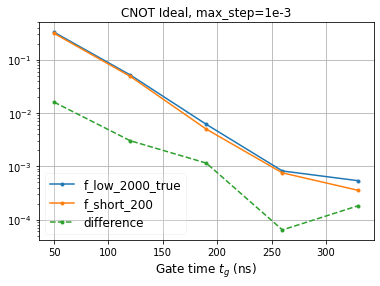

In [8]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(tg_list, 10**f_true_2000[-1,1:], '.-',  label=r'f_low_2000_true')
ax.plot(tg_list, 10**f_short_1000[3,1:], '.-',  label=r'f_short_200')
ax.plot(tg_list, np.abs(10**f_true_2000[-1,1:] - 10**f_short_1000[3,1:]), '.--',  label=r'difference')

plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)', fontsize=12)
plt.title(r'CNOT Ideal, max_step=1e-3', fontsize=12)
plt.grid()
legend = plt.legend(loc='lower left', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

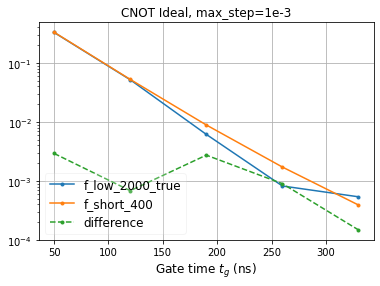

In [7]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(tg_list, 10**f_true_2000[-1,1:], '.-',  label=r'f_low_2000_true')
ax.plot(tg_list, 10**f_short_1000[7,1:], '.-',  label=r'f_short_400')
ax.plot(tg_list, np.abs(10**f_true_2000[-1,1:] - 10**f_short_1000[7,1:]), '.--',  label=r'difference')

plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)', fontsize=12)
plt.title(r'CNOT Ideal, max_step=1e-3', fontsize=12)
plt.grid()
legend = plt.legend(loc='lower left', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

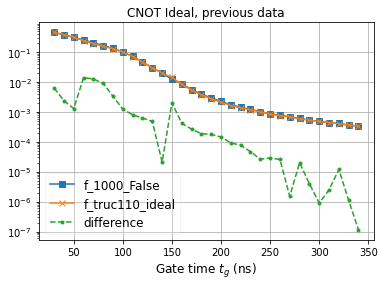

In [59]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(cnot['tg'], 10**cnot['f_1000_False'], 's-',  label=r'f_1000_False')
# ax.plot(cnot['tg'], 10**cnot['f_200_select'], 'x-',  label=r'f_200_select')
# ax.plot(cnot['tg'], np.abs(10**cnot['f_200_select'] - 10**cnot['f_1000_False']), '.--',  label=r'difference')

ax.plot(cnot['tg'], 10**cnot['f_truc110_ideal'], 'x-',  label=r'f_truc110_ideal')
ax.plot(cnot['tg'], np.abs(10**cnot['f_truc110_ideal'] - 10**cnot['f_1000_False']), '.--',  label=r'difference')

plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)', fontsize=12)
plt.title(r'CNOT Ideal, previous data', fontsize=12)
plt.grid()
legend = plt.legend(loc='lower left', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

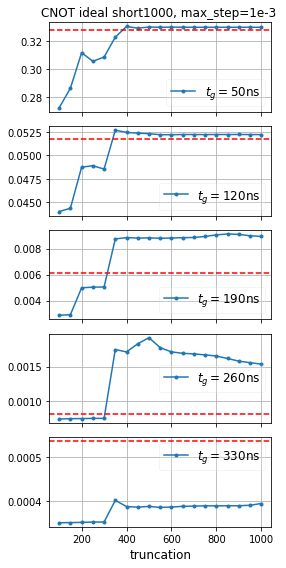

In [ ]:
start = 1

fig, ax = plt.subplots(5, 1, figsize=(4, 8), sharex=True)
for i in range(5):
    ax[i].plot(f_short_1000[start:,0], 10**f_short_1000[start:,i+1], '.-', label=fr'$t_g = {tg_list[i]:.0f}$ns')
    ax[i].axhline(y=10**f_true_2000[39,i+1], linestyle='--', color='red')
    ax[i].grid()
    legend = ax[i].legend(loc="best", fontsize=12)
    legend.get_frame().set_alpha(0.2)
ax[4].set_xlabel('truncation', fontsize=12)
ax[0].set_title(fr'CNOT ideal short1000, max_step=1e-3 ', fontsize=12)
plt.tight_layout()

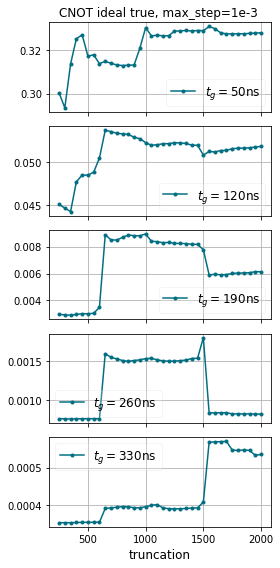

In [44]:
start = 4

fig, ax = plt.subplots(5, 1, figsize=(4, 8), sharex=True)
for i in range(5):
    ax[i].plot(f_true_2000[start:,0], 10**f_true_2000[start:,i+1], '.-', label=fr'$t_g = {tg_list[i]:.0f}$ns')
    ax[i].grid()
    legend = ax[i].legend(loc="best", fontsize=12)
    legend.get_frame().set_alpha(0.2)
ax[4].set_xlabel('truncation', fontsize=12)
ax[0].set_title(fr'CNOT ideal true, max_step=1e-3 ', fontsize=12)
plt.tight_layout()

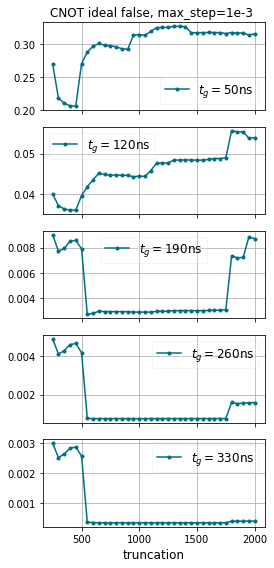

In [43]:
start = 1

fig, ax = plt.subplots(5, 1, figsize=(4, 8), sharex=True)
for i in range(5):
    ax[i].plot(f_false_2000[start:,0], 10**f_false_2000[start:,i+1], '.-', label=fr'$t_g = {tg_list[i]:.0f}$ns')
    # ax[i].set_xscale('log')
    ax[i].grid()
    legend = ax[i].legend(loc="best", fontsize=12)
    legend.get_frame().set_alpha(0.2)
    # ax[i].set_ylabel(fr'$t_g = {params[:,0][i]:.0f}$ns')
ax[4].set_xlabel('truncation', fontsize=12)
ax[0].set_title(fr'CNOT ideal false, max_step=1e-3 ', fontsize=12)
plt.tight_layout()

## previous data

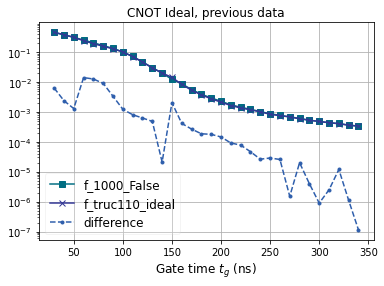

In [7]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(cnot['tg'], 10**cnot['f_1000_False'], 's-',  label=r'f_1000_False')
# ax.plot(cnot['tg'], 10**cnot['f_200_select'], 'x-',  label=r'f_200_select')
# ax.plot(cnot['tg'], np.abs(10**cnot['f_200_select'] - 10**cnot['f_1000_False']), '.--',  label=r'difference')

ax.plot(cnot['tg'], 10**cnot['f_truc110_ideal'], 'x-',  label=r'f_truc110_ideal')
ax.plot(cnot['tg'], np.abs(10**cnot['f_truc110_ideal'] - 10**cnot['f_1000_False']), '.--',  label=r'difference')

plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)', fontsize=12)
plt.title(r'CNOT Ideal, previous data', fontsize=12)
plt.grid()
legend = plt.legend(loc='lower left', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

### Infidelity convergence vs truncation

max_step=1e-3

In [8]:
f_ideal_100_1e3 = np.array([
-0.5608349753564063, -1.3975658834782951, -2.0665457484027208, -2.3235814871678384 ,
-2.535586441845595 ,
])
f_ideal_200_1e3 = np.array([
-0.5737523722918979, -1.4005184860845281, -2.112585440077793, -2.384846244500785 ,
-2.5973475824446344 ,
])
f_ideal_300_1e3 = np.array([
-0.5324359705702385, -1.3502950956175817, -2.5325404418610877, -3.1216704182570187 ,
-3.4526069327265807 ,
])
f_ideal_500_1e3 = np.array([
-0.49865589914762887, -1.314653543012705, -2.5215878831378236, -3.12079239264896 ,
-3.451329268792737 ,
])
f_ideal_1000_1e3 = np.array([
-0.48115027339792227, -1.282133780694707, -2.048601144284009, -2.8133466065899952 ,
-3.4029655386915025 ,
])
truc = [100, 200, 300, 500, 1000]
f_ideal_1e3 = np.column_stack((f_ideal_100_1e3, f_ideal_200_1e3, f_ideal_300_1e3,
                               f_ideal_500_1e3, f_ideal_1000_1e3 ))

In [12]:
truc_true.index(600)

11

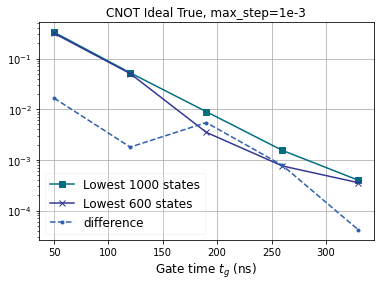

In [13]:
truc = 600
idx = truc_true.index(truc)

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(tg_list, 10**f_true[-1], 's-',  label=r'Lowest 1000 states')
ax.plot(tg_list, 10**f_true[idx], 'x-',  label=f'Lowest {truc} states')
ax.plot(tg_list, np.abs(10**f_true[-1] - 10**f_true[idx]), '.--',  label=r'difference')

plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)', fontsize=12)
plt.title(r'CNOT Ideal True, max_step=1e-3', fontsize=12)
plt.grid()
legend = plt.legend(loc='lower left', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

### Infidelity convergence vs truncation

max_step=1e-4

In [14]:
f_ideal_100_1e4 = np.array([
-0.5608268241656571, -1.3975974586179958, -2.0669584313983314, -2.3244064658170123 ,
-2.536911070070739 ,
])
f_ideal_200_1e4 = np.array([
-0.5737844200138282, -1.4005908979955024, -2.112915635596642, -2.385424076939623 ,
-2.59821471736574 ,
])
f_ideal_300_1e4 = np.array([
-0.53243029381785, -1.350229396988937, -2.532427917610461, -3.1215461634732913 ,
-3.452428649040791 ,
])
f_ideal_500_1e4 = np.array([
-0.4987371586900626, -1.316002596185962, -2.522619428124679, -3.1212413553554574 ,
-3.451383764325859 ,
])
f_ideal_1000_1e4 = np.array([
-0.48107804711348917, -1.2818215524954497, -2.070093844633445, -2.8256327125399876 ,
-3.4156157874624506 ,
])
truc = [100, 200, 300, 500, 1000]
f_ideal_1e4 = np.column_stack((f_ideal_100_1e4, f_ideal_200_1e4, f_ideal_300_1e4,
                               f_ideal_500_1e4, f_ideal_1000_1e4 ))

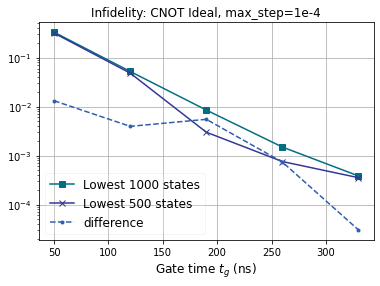

In [15]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(tg_list, 10**f_ideal_1000_1e4, 's-',  label=r'Lowest 1000 states')
ax.plot(tg_list, 10**f_ideal_500_1e4, 'x-',  label=r'Lowest 500 states')
# ax.plot(tg_list, 10**f_ideal_110_3e4, 'x-',  label=r'max_step=3e-4')
ax.plot(tg_list, np.abs(10**f_ideal_1000_1e4 - 10**f_ideal_500_1e4), '.--',  
        label=r'difference')

plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)', fontsize=12)
plt.title(r'Infidelity: CNOT Ideal, max_step=1e-4', fontsize=12)
plt.grid()
legend = plt.legend(loc='lower left', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

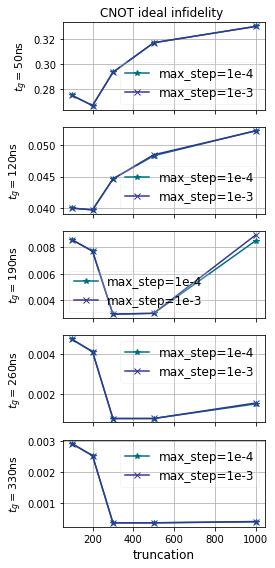

In [16]:
fig, ax = plt.subplots(5, 1, figsize=(4, 8), sharex=True)
for i in range(5):
    ax[i].plot(truc, 10**f_ideal_1e4[i], '*-', label=fr'max_step=1e-4')
    ax[i].plot(truc, 10**f_ideal_1e3[i], 'x-', label=fr'max_step=1e-3')
    # ax[i].set_xscale('log')
    ax[i].grid()
    legend = ax[i].legend(loc="best", fontsize=12)
    legend.get_frame().set_alpha(0.2)
    ax[i].set_ylabel(fr'$t_g = {tg_list[i]:.0f}$ns')
ax[4].set_xlabel('truncation', fontsize=12)
ax[0].set_title(fr'CNOT ideal infidelity ', fontsize=12)
plt.tight_layout()

### Infidelity convergence vs max_step

selected 110 states

In [ ]:
f_ideal_110_1e3 = np.array([
-0.5038292830031199, -1.3267637517474546, -2.5571541981405987, -3.1633836113782117 ,
-3.4805683672062053 ,
])
f_ideal_110_3e4 = np.array([
-0.5037842427356715, -1.3275235452899399, -2.560930477584596, -3.162944692125892 ,
-3.480454078048089 ,
])
f_ideal_110_1e4 = np.array([
-0.5037847247500232, -1.3275244861266038, -2.560914454378997, -3.1629302821063665 ,
-3.480482346346726 ,
])
f_ideal_110_3e5 = np.array([
-0.5037847181945132, -1.32750970283638, -2.560855063529726, -3.1628144010207557 ,
-3.480329379101597 ,
])
f_ideal_110_1e5 = np.array([
-0.5037838909702896, -1.32747855042218, -2.5608442416437165, -3.162872543112692 ,
-3.4804296613776535 ,
])

f_ideal_200_1e3 = np.column_stack((f_ideal_110_1e5, f_ideal_110_3e5, f_ideal_110_1e4, 
                               f_ideal_110_3e4, f_ideal_110_1e3 ))

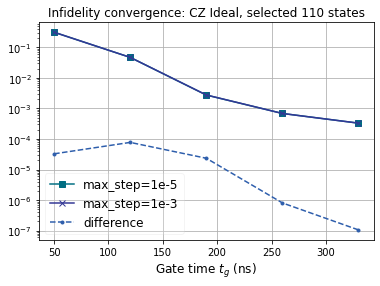

In [18]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(tg_list, 10**f_ideal_110_1e5, 's-',  label=r'max_step=1e-5')
ax.plot(tg_list, 10**f_ideal_110_1e3, 'x-',  label=r'max_step=1e-3')
# ax.plot(tg_list, 10**f_ideal_110_3e4, 'x-',  label=r'max_step=3e-4')
ax.plot(tg_list, np.abs(10**f_ideal_110_1e5 - 10**f_ideal_110_1e3), '.--',  label=r'difference')

plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)', fontsize=12)
plt.title(r'Infidelity convergence: CZ Ideal, selected 110 states', fontsize=12)
plt.grid()
legend = plt.legend(loc='lower left', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

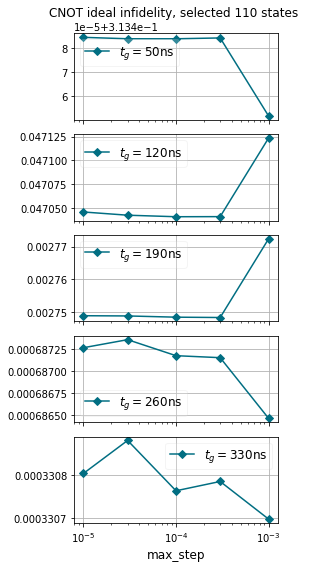

In [ ]:
fig, ax = plt.subplots(5, 1, figsize=(4, 8), sharex=True)
for i in range(5):
    ax[i].plot(msteps, 10**f_ideal_200_1e3[i], 'D-', label=fr'$t_g = {tg_list[i]:.0f}$ns')
    ax[i].set_xscale('log')
    ax[i].grid()
    legend = ax[i].legend(loc="best", fontsize=12)
    legend.get_frame().set_alpha(0.2)
    # ax[i].set_ylabel(fr'$t_g = {params[:,0][i]:.0f}$ns')
ax[4].set_xlabel('max_step', fontsize=12)
ax[0].set_title(fr'CNOT ideal infidelity, selected 110 states ', fontsize=12)
plt.tight_layout()

### get ratio between dephasing and decay

In [20]:
# CZ,170us, truncation=40,
tg = [32,74,116,158,200]
f_ideal = [ -0.37162705, -1.35908602, -2.90767694, -3.59798188 , -3.95481693 , ]
f_decay = [ -0.37161628, -1.35892836, -2.90185895, -3.57113501 , -3.89801909 , ]
f_dephase = [ -0.37158271, -1.35821592, -2.85902110, -3.36419611 , -3.48048711 , ]
f_both = [ -0.37158805, -1.35813258, -2.85745975, -3.36192231 , -3.47917535 , ]
def ratio(f_dephase, f_decay):
    return round(10**(f_dephase) / 10**(f_decay), 2)
lst = [ratio(a,b) for a, b in zip(f_dephase, f_decay)]
print(lst)
print(' (1-F_dephase) / (1-F_decay), tg=55,116ns, truncation=78,40')
print(f'xgate_170μs = {10**(-3.896) / 10**(-4.244):.2f}') # xgate 170 us
print(f'xgate_3μs = {10**(-2.234) / 10**(-2.722):.2f}') # xgate 3 us
print(f'cz_170μs = {10**(-2.859) / 10**(-2.902):.2f}') # cz 170 us
print(f'cz_3μs = {10**(-2.121) / 10**(-2.738):.2f}') # cz 3 us

[1.0, 1.0, 1.1, 1.61, 2.62]
 (1-F_dephase) / (1-F_decay), tg=55,116ns, truncation=78,40
xgate_170μs = 2.23
xgate_3μs = 3.08
cz_170μs = 1.10
cz_3μs = 4.14


### get meadian amplitude and detune from pulse parameters

In [21]:
print(np.mean(cnot['detune_1']), np.mean(cnot['detune_2']))
print(cnot['detune_1'].median(), cnot['detune_2'].median())
print(np.mean(cnot['drive_amp_1']), np.mean(cnot['drive_amp_2']))
print(cnot['drive_amp_1'].median(), cnot['drive_amp_2'].median())

-0.0092455 -0.0088359375
-0.006548 -0.006191
0.040890499999999996 0.0233651875
0.031868 0.020352500000000003


In [22]:
=

SyntaxError: invalid syntax (<ipython-input-22-9ae22869553b>, line 1)